## Part 0: Introduction and preparation

Welcome to the Large Language Model (LLM) project of ELEN90088!

In this project, you will transition from a consumer of AI to an engineer who understands the mechanics of LLMs. You will explore how these models are loaded, manipulated, trained and optimized to run on GPUs.

This project focuses on implementation and engineering. While the theories behind the transformer architecture (Attention, LayerNorm etc.) may be covered in lectures, you will not be asked to implement
these components from scratch (note that we may ask you to explain attention mechnaisms from a high level, but not in detail). Instead, you will learn to use the HuggingFace library to leverage these components.

This project is structured into six parts. You will follow the notebook to get familiar with LLMs in part 1-5, and design your own mini-project in part 6.

Specifically, this project includes the following parts:
1. The `pipeline`: Use high-level LLM APIs to perform tasks like sentiment analysis and text generation.
2. Behind the `pipeline`: Understand and manage the key components of LLM workflow, including tokenizers, models and datasets.
3. Inference: Use the tools from part 2 to implement the `pipeline` in part 1.
4. Efficient LLM - Model Compression: Reduce the LLM size while maintaining the LLM performance.
5. Efficient LLM - Parameter-efficient Fine-Tuning (PEFT): Use advanced methods to specialize a general-purpose model for specific tasks.
6. Mini-project: Design and implement your own LLM project with the skills you have learned from part 1-5.

Notes:
1. GPU usage: for part 1-2, cpu may be sufficient (loading models for a few minutes is normal). From part 3, you will need access to GPU (Google Colab, and/or Windows with Nvidia) or MPS (on Mac).
2. Project report: This notebook includes some questions that help you understand more details about LLM and implemetation. These questions are labelled as "**Questions (for project report)**". You may prepare the responses to these questions as part of your report.
3. Get help: While this notebook was prepared to explain as much terminology as possible, you may find some definitions unfamilar and need time to process. This is perfectly normal especially for beginners. You are encouraged to find other guidelines, technical reports and blogs from Google and/or AI. For example, what is a BERT model and what does it do? We will test your understanding during oral exams.
4. Code: Most of the code in part 1-5 has been provided to you. We also left some parts for you to implement as exercises.
   
    That said, instead of just running the cells, we highly recommend you to understand **why** the code works, and how you could modify some parameters, variables to improve the code performance. We will test whether you **really** understand the code during oral exams. 
5. (**Important**) Mistral vs. Phi LLM. As you will see, starting from part 2, this notebook frequently talks about the Mistral model, and the code is often about the Mistral model. While Mistral has great functionalities, it may not be feasible to run Mistral models on your hardware, which is perfectly fine becuase there are other models that can run on your hardware.

    If you are using standard hardware (eg. Macbook Pro, or Colab free tier), we recommend you to use Phi model from Microsoft, which we have tested and confirmed it will run on your hardware and the free version of Google Colab. The only change you need to make is to ensure you are loading and using Phi model (not Mistral which may crash your code) where necessary. 
    
    For the tasks that you may use Phi model and update the code (written for Mistral models), we have added a note: "**(You can use Phi model for this task, please modify the code if requried)**" 

    Your project marks are **not** affected by which model you use.

6. Oral exam: We will test your understanding of this notebook, including but not limited to (your answers to) "**Questions (for project report)**", code details, and your mini project during oral exams.

In [1]:
import os
import torch
import time
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
from datasets import load_dataset
import pandas as pd

W0603 16:21:42.177000 11012 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [6]:
# Define the device selector
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [15]:
import sys
print(f"Python is running from: {sys.executable}")
print(f"Torch is installed in: {torch.__file__}")

Python is running from: c:\Users\james\anaconda3\envs\soml_llm_env\python.exe
Torch is installed in: c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\torch\__init__.py


In [1]:
# uncomment the line below to check GPU status (not examinable)
!nvidia-smi

Tue May 12 16:27:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.21                 Driver Version: 596.21         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:64:00.0 Off |                  N/A |
| N/A   55C    P2             12W /   60W |       0MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Some checks to make sure the project environment will work (not examinable)

from huggingface_hub import split_torch_state_dict_into_shards
print("Successfully imported!")

Successfully imported!


In [6]:
# Some checks to make sure the project environment will work (not examinable)

import transformers
from packaging import version

required_version = "4.34.0"
current_version = transformers.__version__

if version.parse(current_version) < version.parse(required_version):
    print(f"❌ ERROR: Your transformers version ({current_version}) is too old!")
    print(f"Please run: pip install -U transformers")
else:
    print(f"✅ SUCCESS: Transformers version {current_version} is compatible with Mistral.")

✅ SUCCESS: Transformers version 4.40.0 is compatible with Mistral.


## Part 1: Warm up, LLM pipeline

In this part, we will treat LLMs as a black box. We will use the Hugging Face `pipeline` API, which abstracts the complexities of tokenization, model architecture and output decoding into a single line of code.

### Example 1a: Autoregressive Text Generation

Unlike classification in other neurnal network applications, text generation is a generative task. The model predicts possible next token based on all previous tokens in the sequence.

In [16]:
generator = pipeline("text-generation", model="gpt2", tokenizer="gpt2")
generator(
    "In this LLM project, we will teach you how to",
    max_new_tokens=50,
    pad_token_id=generator.tokenizer.eos_token_id
)

[{'generated_text': "In this LLM project, we will teach you how to write your own and show how to use LLVM's open source code for C++.\n\nHere are the examples of code examples in this LLM project that teach us how to write a good C++ code. You can see the C header"}]

**Questions (for project report)**

- Did you get some warning messages or errors? If the warning messages (or notes) did not stop you from running the cell above, what could you do to eliminate the warning?

**Hint**: you may want to specify a model, explain `gpt2` model, and understand `pad_token_id`, `eos_token_id`. You may also change the string in `generator` and discuss the quality of generated text, does the output text make sense?

### Example 1b: Sentiment analysis

The goal of sentiment analysis is to claassify a string of text into a category (eg. Positive or Negative). This is a discriminative task, not a text generation task.

In [8]:
classifier = pipeline("sentiment-analysis", model = "distilbert-base-uncased-finetuned-sst-2-english")

texts = [
    "How good is ELEN90088",
    "I really enjoyed this subject.",
    "This project is confusing and frustrating.",
    "The lecture had many issues which were disliked, very slow, but still just okay."
]

results = classifier(texts)

for text, result in zip(texts, results):
    print(f"Text: {text}")
    print(f"Label: {result['label']}")
    print(f"Score: {result['score']:.4f}")
    print()

Text: How good is ELEN90088
Label: POSITIVE
Score: 0.9998

Text: I really enjoyed this subject.
Label: POSITIVE
Score: 0.9999

Text: This project is confusing and frustrating.
Label: NEGATIVE
Score: 0.9996

Text: The lecture had many issues which were disliked, very slow, but still just okay.
Label: POSITIVE
Score: 0.9986



**Questions (for project report)**

You will see something like "No model was supplied, defaulted to **distilbert**/distilbert-base-uncased-finetuned-sst-2-english"

- What's BERT, how's that different from other models (eg. GPT-2)?

- What's `distilbert`? What's `distilbert-base-uncased-finetuned-sst-2-english`?

- What are `label` and `score`? Can you try different sentiment and check the output `label` and `score`?

### Exploring `pipeline`

Hugging Face offers dozens of pre-configured pipelines for differentt modalities. Now that you have seen how `pipeline()` works (twice), it is your turn to explore.

### Exercise:

Choose another two `pipeline()` tasks (that's not sentiment analysis or text generation) and implement them in the cells below. Also briefly explain the tasks and their performance in your report. For example, does the model output meet your expectations?

**Hint**: This link might help. https://huggingface.co/docs/transformers/en/main_classes/pipelines

In [9]:
# pipeline() Task 1
# Question Answering

question_answer = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")
    

context = """
System Optimisation and Machine Learning
is a subject that first introduces convex optimisation problems,
how to solve them using gradient descent and other algorithms. 
It then introduces machine learning concepts and techniques, such as
supervised learning, unsupervised learning, and deep learning.
"""

question = "What is taught in the System Optimisation and Machine Learning subject?"
result = question_answer(question=question, context=context)

print(f"Question: {question}")
print(f"Answer: {result['answer']}")
print(f"Score: {result['score']:.4f}")

Question: What is taught in the System Optimisation and Machine Learning subject?
Answer: convex optimisation problems
Score: 0.1854


In [10]:
# pipeline() Task 2
# Named Entity Recognition
ner_pipeline = pipeline( "ner", model="dslim/bert-base-NER", aggregation_strategy="simple")

text = "My names is James Condos, and I take ELEN90088 at the University of Melbourne."
results = ner_pipeline(text)

print(f"Text: {text}\n")

for entity in results:
    print(f"Entity: {entity['word']}")
    print(f"Type: {entity['entity_group']}")
    print(f"Score: {entity['score']:.4f}")
    print()

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Text: My names is James Condos, and I take ELEN90088 at the University of Melbourne.

Entity: James Condos
Type: PER
Score: 0.9987

Entity: E
Type: ORG
Score: 0.4335

Entity: University of Melbourne
Type: ORG
Score: 0.9969



**Questions (for project report)**

- While the `pipeline()` API is easy to use (two lines of code), it hides several critical steps of LLM workflow. Based on your observation of execution time, what do you think is happening when you call the `pipeline()` function for the first time vs. the second time? Briefly explain in your report.

## Part 2: Behind the pipeline - LLM workflow

While the `pipeline()` API is convenient, it abstracts away the engineering decisions required for high-performance systems. To optimize for memory and/or speed, we must gain granular control over the individual components of the LLM workflow. Key components in the workflow include the tokenizer, the model and the datasets.

#### The choice of model
For this part, we are using Mistral-7B-Instruct-v0.3 for a few reasons:

- It is widely considered one of the best models in the "7-Billion parameter" class, outperforming some models twice its size.
- Since it has been fine-tuned to follow instructions, it is highly capable of performing zero-shot and few shot tasks we will attempt in Part 3.

**Note:** For part 2, you should be able to load Mistral model with any hardware. However when you start inference in next parts, your hardware may not be able to handle Mistral. Don't panic, you can use Phi model instead.
  
#### Manage storage (**Optional**)

When you download an LLM, you are downloading massive files. For example, the Mistral weights alone are around 14.5 GB. By default, Hugging Face saves these in a hidden folder in your Home directory (eg. `~/.cache/huggingface` on Mac OS). This could become tricky if you download a few models and datasets without checking and managing disk storage. A simple method to get easy access to the downloaded files (and manage them) is to create a cache folder within your project directory, and download all the project files in this dedicated cache folder.

**Note:** While this is recommended, setting up this cache folder is optional and will not affect your project marks.

In [8]:
#cache_dir = "./project_cache"

**(You can use Phi model for this task, please modify the code if requried)**

In [2]:
#model_id = "mistralai/Mistral-7B-Instruct-v0.3" #we use Mistral instruct model for this part

# Uncomment below if you want to use Phi model: it's easier to run on local device and free Colab!
model_id = "microsoft/Phi-3.5-mini-instruct"
cache_dir = "./phi_project"

#### 2.1 The tokennizer

Computers process numbers, not text. The tokenizer acts as the "translator" between human language and the high-dimensional vectors the model understands. It performs three critical steps:

1. Normalization: Removing extra spaces, lowercase conversion, etc.
2. Pre-tokenization: Splitting text intowords or sub-words.
3. Encoding: Mapping those sub-words to their unique integer IDs in the model's vocabulary.

It is a fundamental requirement that your tokenizer and model come from the exact same "designer" and version (in this part, we use the Mistral model). If they don't match, for example, we load a Llama-3 tokenizer with a Mistral model, the system will not necessaricly throw a code error, but the results will likely be ungrammatical texts. Every model is trained with a specific Vocabulary index. If a tokenizer tells the Mistral model that the ID `5678` means "Apple", but the Mistral model and tokenizer was trained to believe `5678` means "float", then the mathematical logic of the network will collapse.

#### Exercise:

Load the tokenizer and observe how it handles the Mistral/Phi vocabulary.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    use_fast=False,
    cache_dir=cache_dir # Note that we specified the cache folder here and in the next parts where we load models, tokenizers etc.
)


text = "Optimization is essential for LLMs."
ids = tokenizer.encode(text)

print(f"Token IDs: {ids}")
print(f"Decoded: {tokenizer.decode(ids)}")

# more examples...
print(f"Decoded: {tokenizer.decode(5678)}")

c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Token IDs: [20693, 326, 2133, 338, 18853, 363, 365, 26369, 29879, 29889]
Decoded: Optimization is essential for LLMs.
Decoded: Ros


In [5]:
# more examples...
text1 = "Advancements"
text2 = "Knowledgeable"
list_of_texts = [text1, text2]

ids = tokenizer.encode(text)

print(f"Token IDs: {ids}")

for text in list_of_texts:
    ids = tokenizer.encode(text)
    for token in ids:
        print(f"Decoded token ID {token}: {tokenizer.decode(token)}")

#print(f"Decoded: {tokenizer.decode(17393)}")

Token IDs: [20693, 326, 2133, 338, 18853, 363, 365, 26369, 29879, 29889]
Decoded token ID 2087: Ad
Decoded token ID 3703: van
Decoded token ID 29883: c
Decoded token ID 4110: ements
Decoded token ID 19320: Know
Decoded token ID 5485: ledge
Decoded token ID 519: able


**Questions (for project report)**

- A token can be a word, or part of a word. For example, "tokenization" includes "token" and "ization". Can you find other words that consist of multiple tokens?

- Can you explain why tokenization may be a good approach to turn texts into numbers? **Hint:** What would happen if every word was represented by an unique integer?

#### 2.2 The model

In the Hugging Face ecosystem, "the model" is the computational heart of the system that has a collection of billions of pre-trained weights organized into a specific neural architecture. While the tokeizer handles the text-to-ID translation, the model performs the massive matrix multiplication required to predict the probability of the next token in a sequence.

LLMs typically store weights using floating-point numbers. While standard software often use 32-bit (Float32), moden LLMs utilize 16-bit formats like Float16. This format provides the same dynamic range as Float32 but with half the memory footprint, offering a crucial balance between numerical stability and hardware efficiency. We will dive deeper into the these data types and how they reduce model size in part 4.

#### Exercise:

Run the following code to load the model.


**(You can use Phi model for this task, please modify the code if requried)**

In [8]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

True
NVIDIA GeForce RTX 5060 Laptop GPU


In [14]:
print("Loading raw model (16-bit baseline)...")
model_raw = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    cache_dir=cache_dir, trust_remote_code = True
)

print(f"Model successfully loaded on: {model_raw.device}")
print(f"Model precision: {model_raw.dtype}")

Loading raw model (16-bit baseline)...


`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model successfully loaded on: cuda:0
Model precision: torch.bfloat16


In [7]:
# Check the device of the model parameters
print(next(model_raw.parameters()).device)


config = model_raw.config

print("Architecture:", config.architectures)
print("Model type:", config.model_type)
print("Number of layers:", config.num_hidden_layers)
print("Hidden size:", config.hidden_size)
print("Intermediate size:", config.intermediate_size)
print("Attention heads:", config.num_attention_heads)
print("Key/value heads:", config.num_key_value_heads)
print("Head dimension:", config.hidden_size // config.num_attention_heads)
print("Max position embeddings:", config.max_position_embeddings)
print("Sliding window:", config.sliding_window)
print("Vocabulary size:", config.vocab_size)

cuda:0
Architecture: ['Phi3ForCausalLM']
Model type: phi3
Number of layers: 32
Hidden size: 3072
Intermediate size: 8192
Attention heads: 32
Key/value heads: 32
Head dimension: 96
Max position embeddings: 131072
Sliding window: 262144
Vocabulary size: 32064


**Questions (for project report)**

- How can you confirm whether your model is loaded on CPU or GPU?

- Explore model architecture (attention heads, sliding window etc.). It's perfectly fine to use online resources to understand the architecture (please cite your sources). It's even better to verify the online resources by running some simple code to show the structure (eg. layer names) of the loaded model.

#### Save and load from local path

In professional workflows, you often need to save a specific state of a model to ensure reproducibility or to move it between computing nodes without relying on an internet connection. By using `save_pretrained()`, you create a local snapshot of the model weights and configuration files. We will use this path again in part 4.

**(You can use Phi model for this task, please modify the code if requried)**

In [11]:
from pathlib import Path
import shutil

# Save the model and tokenizer to a fresh local directory.
# Use a new folder so stale index files from older failed saves cannot be reused.
local_path = "./phi_16bit_save_clean"
save_path = Path(local_path)

if save_path.exists():
    shutil.rmtree(save_path)

model_raw.save_pretrained(
    local_path,
    safe_serialization=False,
    max_shard_size="2GB"
)
tokenizer.save_pretrained(local_path)

print(f"Saved clean local checkpoint to: {local_path}")
print("Saved files:")
for path in sorted(save_path.iterdir()):
    print(f"- {path.name}")

Saved clean local checkpoint to: ./phi_16bit_save_clean
Saved files:
- added_tokens.json
- config.json
- generation_config.json
- pytorch_model-00001-of-00004.bin
- pytorch_model-00002-of-00004.bin
- pytorch_model-00003-of-00004.bin
- pytorch_model-00004-of-00004.bin
- pytorch_model.bin.index.json
- special_tokens_map.json
- tokenizer.model
- tokenizer_config.json


To load the model from your saved files instead of downloading (every time) from the Hugging Face hub, simply replace the `model_id` with your local directory path. The library will detect that you are pointing to a folder rather than a remote repository name.

In [4]:
from pathlib import Path
from huggingface_hub import snapshot_download
import gc

# Use the already-downloaded Hugging Face cache snapshot as the local path.
# This avoids reloading from an incomplete or incompatible re-saved checkpoint.
local_path = snapshot_download(
    repo_id=model_id,
    cache_dir=cache_dir,
    local_files_only=True
)
offload_dir = "./offload_dir"
checkpoint_path = Path(local_path)

print(f"Loading from local snapshot: {checkpoint_path}")

# Free the original model before reloading it from disk. This avoids keeping two Phi models in memory.
if "model_raw" in globals():
    del model_raw
if "model_local" in globals():
    del model_local
if "model" in globals():
    del model

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model_local = AutoModelForCausalLM.from_pretrained(
    local_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    offload_folder=offload_dir,
    offload_state_dict=True,
    trust_remote_code=True,
    local_files_only=True,
    use_safetensors=True,
    attn_implementation="eager"
)

tokenizer_local = AutoTokenizer.from_pretrained(
    local_path,
    trust_remote_code=True,
    local_files_only=True
)

# Keep later notebook cells compatible with the original variable names.
model_raw = model_local
model = model_local
tokenizer = tokenizer_local

print(f"Loaded local model from: {local_path}")
print(f"Model device: {next(model_local.parameters()).device}")

Loading from local snapshot: phi_project\models--microsoft--Phi-3.5-mini-instruct\snapshots\2fe192450127e6a83f7441aef6e3ca586c338b77


`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loaded local model from: ./phi_project\models--microsoft--Phi-3.5-mini-instruct\snapshots\2fe192450127e6a83f7441aef6e3ca586c338b77
Model device: cuda:0


#### Clean up memory (**Optional**)

The function below can clean up your GPU memory so that you can load and try new models without receiving 'out-of-memory' errors.

In [23]:
import gc
import sys
import torch

def reset_gpu_memory(*model_variable_names):
    """
    Delete model variables, clear IPython output references, and clear unused CUDA cache.
    Use this before switching between model types.
    """
    for model_variable_name in model_variable_names:
        if model_variable_name in globals():
            print(f"--- Deleting {model_variable_name} from memory ---")
            del globals()[model_variable_name]
        else:
            print(f"--- No variable named '{model_variable_name}' found ---")

    # Delete any other top-level torch modules that may still be present.
    for name, value in list(globals().items()):
        if isinstance(value, torch.nn.Module):
            print(f"--- Deleting torch module '{name}' from memory ---")
            del globals()[name]

    # Clear IPython's output/history references, which can keep large objects alive.
    try:
        ipython = get_ipython()
        if ipython is not None:
            ipython.user_ns.pop("_", None)
            ipython.user_ns.pop("__", None)
            ipython.user_ns.pop("___", None)
            ipython.user_ns.get("Out", {}).clear()
    except NameError:
        pass

    # Clear references held by the last exception traceback.
    for attr in ("last_traceback", "last_value", "last_type"):
        if hasattr(sys, attr):
            setattr(sys, attr, None)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.synchronize()
        print("VRAM cache cleared.")
        print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
        print(f"GPU Memory Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
    else:
        print("No GPU detected to clear.")

reset_gpu_memory(
    "model",
    "model_raw",
    "model_local",
    "model_16bit",
    "model_4bit",
    "peft_model_16bit",
    "qlora_model"
)

--- No variable named 'model' found ---
--- No variable named 'model_raw' found ---
--- No variable named 'model_local' found ---
--- No variable named 'model_16bit' found ---
--- No variable named 'model_4bit' found ---
--- No variable named 'peft_model_16bit' found ---
--- No variable named 'qlora_model' found ---
VRAM cache cleared.
GPU Memory Allocated: 5.90 GB
GPU Memory Reserved: 5.90 GB


#### Check GPU memory (**Optional**)

The function below can check your GPU resources. Note that we recommended to use your own device (if it has a GPU) and/or FEIT GPU Desktop. 

If you use the free version of Google Colab you will see the allocated and reserved memory are very low, which would not be suffifient for this project. 

In [1]:
import torch

def print_gpu_utilization():
    if torch.cuda.is_available():
        # Returns memory in bytes, so we convert to GB
        used_memory = torch.cuda.memory_allocated() / 1024**3
        reserved_memory = torch.cuda.memory_reserved() / 1024**3
        print(f"GPU Memory Allocated: {used_memory:.2f} GB")
        print(f"GPU Memory Reserved: {reserved_memory:.2f} GB")
    else:
        print("No GPU detected.")

# Check before loading Mistral
print_gpu_utilization()

GPU Memory Allocated: 0.00 GB
GPU Memory Reserved: 0.00 GB


#### 2.3 A note on datasets

While we have loaded our tokenizer and model, a LLM workflow in incomplete without data. You may have noticed we have not included the code to process any datasets in this part. We will introduce the dataset in part 3, where we will write the logic to feed data into the model.

## Part 3: Inference Engineering

In this part, you will use the tokenizer and the model you loaded in part 2 to implement the `pipeline` tasks from part 1.

By handling the tensors, you will observe the "autoregressive" nature of LLMs: how they predict the next token based on the previous context, and how prompt engineering can turn a general-purpose text generator into a specialized classifier.

### Part 3a: Text response with LLM

In example 1a, the `pipeline` handled the iteration of predicting word after word. Now, you will implement this manually.

For part 3a, you will learn to use the `model.generate()` function, which gives you control over variables like `temperature` (creativity) and `max new tokens` (output length).

**(You can use Phi model for this task, please modify the code if requried)**

In particular, you would want to search the correct instruction formatr for Phi model, which is different from Mistral.

In [5]:
# 1. Setup - Use the same ID and directory from previous tasks
# model_id = "mistralai/Mistral-7B-Instruct-v0.3"
# cache_dir = "./mistral_project"

# Uncomment below if you want to use Phi model: it's easier to run on local device and free Colab!
# You may have small issues to run the code below with Phi model but they can be quickly fixed (no need to panic at all). You can search on Google, use AI, or talk to demonstrators.
model_id = "microsoft/Phi-3.5-mini-instruct"
cache_dir = "./phi_project"

# 2. Load the Components
tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir=cache_dir)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16, # Baseline precision
    device_map="auto",
    cache_dir=cache_dir, trust_remote_code = 'True'
)

def generate_text(user_prompt, max_tokens=100, temperature=0.7, do_sample_state = True):
    """
    Manually handles the prompt encoding, generation, and decoding.
    """
    # Wrap in Mistral's required instruction format [INST] [/INST]
    # What's Phi's instruction format?
    formatted_prompt = f"[INST] {user_prompt} [/INST]"

    # Step A: Tokenization (Text -> IDs)
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")

    # Step B: Generation
    # We use 'do_sample=True' to allow for creativity via Temperature


    if do_sample_state:

        output_tokens = model.generate(
            **inputs,
            max_new_tokens = max_tokens,
            temperature = temperature,
            do_sample = do_sample_state,
            pad_token_id = tokenizer.eos_token_id
        )

    else:

        output_tokens = model.generate(
            **inputs,
            max_new_tokens = max_tokens,
            do_sample = do_sample_state,
            pad_token_id = tokenizer.eos_token_id
        )



    # Step C: Decoding (IDs -> Text)
    # We slice the output to remove the original prompt from the display
    new_tokens = output_tokens[0][len(inputs["input_ids"][0]):]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)

    return response

c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [25]:
# --- Test the Function ---
my_prompt = "Outline an introduction to LLM for students with some maths and programming background"
print(f"Prompt: {my_prompt}\n")

#print(f"Response:\n{generate_text(my_prompt, max_tokens = 1000)}") # With max_tokens=1000, you may need to wait more than 5 minutes to get the output. You can set a smaller max_tokens first, confirm the code is working, and then switch to larger max_tokens.
#print(f"Response:\n{generate_text(my_prompt, max_tokens = 1000)}")
print(f"Response:\n{generate_text(my_prompt, max_tokens = 1000, temperature = 0.1)}")
print(f"Response:\n{generate_text(my_prompt, max_tokens = 1000, temperature = 1)}")
print(f"Response:\n{generate_text(my_prompt, max_tokens = 1000, do_sample_state = False)}")

Prompt: Outline an introduction to LLM for students with some maths and programming background

Response:
Introduction to Large Language Models (LLMs) for Students with Maths and Programming Background

Hello students,

Welcome to this introduction to Large Language Models (LLMs), a fascinating intersection of natural language processing (NLP), machine learning (ML), and programming. If you have a background in mathematics and programming, you're well-positioned to understand and appreciate the complexities and potential of LLMs.

Here's a structured outline to help you navigate through this topic:

1. **Understanding Language Models**
   - **Definition**: A language model is a statistical model that predicts the likelihood of a sequence of words. It's a foundational concept in NLP.
   - **Mathematical Basis**: Language models often use probability distributions, such as n-gram models, which calculate the probability of a word given the previous n-1 words.
   - **Connection to Programm

**Questions (for project report)**

- How does the output relate to the prompt? Does it talk about LLM as in 'Large Language Models'? If you run the above code again, does the output change?

- How could you make sure the output talks about Large Language Models?

- In step B of `generate_text` function, there are a few variables that you can adjust. 
    - Explain `max_new_tokens`, `temperature`, `do_sample`.
    - Change these variables and observe the output.

### Part 3b: Sentiment Analysis with LLM

In example 1b, you used a BERT-based model for sentiment analysis. BERT is an encoder-only model designed to output a numerical score for a fixed set of labels.

In part 3b, we take a different approach using a generative LLM. We don't use a classification "head" in LLM architecture, instead, we use prompts. By providing the model with a clear instruction (and optionally a few examples), we "steer" the model to output exactly one word: `Positive` or `Negative` (sentiment).

Unlike BERT, an LLM can technically say whatever it wants. If your prompt is vague, the LLM might explain why it thinks an input is positive instead of just giving the positive/negative label. You will explore how to constrain the output to ensure it fits back into your workflow.

**Note**: While BERT is efficient for simple classification, the industry is shifting toward generative inference, which can achieve:
- Zero-shot capabilities: How a model can perform a task it wasn't explicit trained for.
- Instruction following: How the `[INST]` and `[/INST]` tags change the probability distribution of the next token.
- Unified architecture: the power of using one single model for both generation and classification.

#### Exercise: Simple sentiment analysis

Fill in the code below. Use Mistral and text generation function to complete sentiment analysis tasks. **Hint**: Check the code in part 3a.

**(You can use Phi model for this task, please modify the code if requried)**

In particular, you would want to search the correct instruction formatr for Phi model, which is different from Mistral.

In [1]:
#********************************PART 3A CODE*********************************
# # 1. Setup - Use the same ID and directory from previous tasks
# # model_id = "mistralai/Mistral-7B-Instruct-v0.3"
# # cache_dir = "./mistral_project"

# # Uncomment below if you want to use Phi model: it's easier to run on local device and free Colab!
# # You may have small issues to run the code below with Phi model but they can be quickly fixed (no need to panic at all). You can search on Google, use AI, or talk to demonstrators.
# model_id = "microsoft/Phi-3.5-mini-instruct"
# cache_dir = "./phi_project"

# # 2. Load the Components
# tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir=cache_dir)
# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     torch_dtype=torch.bfloat16, # Baseline precision
#     device_map="auto",
#     cache_dir=cache_dir, trust_remote_code = 'True'
# )

# def generate_text(user_prompt, max_tokens=100, temperature=0.7, do_sample_state = True):
#     """
#     Manually handles the prompt encoding, generation, and decoding.
#     """
#     # Wrap in Mistral's required instruction format [INST] [/INST]
#     # What's Phi's instruction format?
#     formatted_prompt = f"[INST] {user_prompt} [/INST]"

#     # Step A: Tokenization (Text -> IDs)
#     inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")

#     # Step B: Generation
#     # We use 'do_sample=True' to allow for creativity via Temperature


#     if do_sample_state:

#         output_tokens = model.generate(
#             **inputs,
#             max_new_tokens = max_tokens,
#             temperature = temperature,
#             do_sample = do_sample_state,
#             pad_token_id = tokenizer.eos_token_id
#         )

#     else:

#         output_tokens = model.generate(
#             **inputs,
#             max_new_tokens = max_tokens,
#             do_sample = do_sample_state,
#             pad_token_id = tokenizer.eos_token_id
#         )



#     # Step C: Decoding (IDs -> Text)
#     # We slice the output to remove the original prompt from the display
#     new_tokens = output_tokens[0][len(inputs["input_ids"][0]):]
#     response = tokenizer.decode(new_tokens, skip_special_tokens=True)

#     return response

In [17]:
def format_instruction(user_prompt):
    messages = [{"role": "user", "content": user_prompt}]

    if getattr(tokenizer, "chat_template", None):
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

    return f"<|user|>\n{user_prompt}<|end|>\n<|assistant|>\n"


def get_model_device():
    return next(model.parameters()).device


def extract_sentiment_label(output_tokens, inputs):
    generated_tokens = output_tokens[0][inputs["input_ids"].shape[-1]:]

    response = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

    return response


def get_sentiment(review):
    user_prompt = (
        "Classify the sentiment of the review below. "
        "Output exactly one word: Positive or Negative.\n\n"
        f"Review: {review}\n"
        "Sentiment:"
    )
    prompt = format_instruction(user_prompt)
    inputs = tokenizer(prompt, return_tensors="pt").to(get_model_device())

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    return extract_sentiment_label(output, inputs)


# Example Test
print(get_sentiment("I both love you more than I dislike you"))
# Expected Output: Positive

Positive


Now we move beyond simple generation to evaluate how Mistral-7B handles semantic complexity. We will compare two fundamental paradigms of In-Context Learning:
- Zero-shot learning: The model is given a task description and a test input with no prior examples. This relies entirely on the model's pre-trained internal knowledge and instruction-following capabilities.
- Few-shot learning: We provide a "context" of a few labeled examples (k-shot) before the test input. This helps the model align with the desired output format and grasp the specific "logic" of the task.

Standard sentiment analysis often relies simple keyword matching (e.g. "good" = positive). However, human language is rarely that simple. The examples below contains linguistic traps including:
- Sarcasm: "Oh great, another 'groundbreaking' superhero movie!"
- Negation/Double negatives: "I can't believe how much I didn't hate this."
- Contrastive conjuctions: "The plot was non-existent... yet I couldn't look away."
- Backhanded compliments: "This is the best example of a terrible movie."

By comparing zero-shot vs. few-shot performance on these examples, you will observe how providing even a tiny bit of context can help the model navigate complex intent.

#### Exercise: Sentiment analysis of "tricky" sentences

Fill in the code below and compare zero-shot and few-shot performance.

**(You can use Phi model for this task, please modify the code if requried)**

In particular, you would want to search the correct instruction formatr for Phi model, which is different from Mistral.

In [27]:
# 1. Setup the Evaluation Data
tricky_reviews = [
    "I was worried it would be terrible, but it actually wasn't bad at all.",
    "Oh great, another 'groundbreaking' superhero movie that is exactly like the last ten.",
    "The plot was non-existent and the acting was wooden, yet I couldn't look away.",
    "It’s not that the food was cold, it’s just that it wasn't particularly warm either.",
    "If you enjoy watching paint dry, you'll love this movie!",
    "I've had better, but I've certainly had much, much worse.",
    "Everything about this place is perfect, except for the service, the food, and the price.",
    "I can't believe how much I didn't hate this.",
    "I was furious when the concert ended because I wanted another hour.",
    "This is the best example of a terrible movie I have ever seen.",
    "The only thing more disappointing than the ending was the fact that I paid for a ticket."
]

# 2. Define the Prompt Templates
def get_zero_shot_prompt(review):
    user_prompt = (
        "Classify the sentiment of the review below. "
        "Output exactly one word: Positive or Negative.\n\n"
        f"Review: {review}\n"
        "Sentiment:"
    )
    return format_instruction(user_prompt)


def get_few_shot_prompt(review):
    user_prompt = f"""Classify each review as Positive or Negative.
Output exactly one word: Positive or Negative.

Examples:
Review: "The story was slow at first, but the ending made it worthwhile." -> Positive
Review: "The staff smiled a lot, but the food was cold and overpriced." -> Negative
Review: "The food was not freezing, but it was not warm or enjoyable either." -> Negative
Review: "I expected to hate this, but I had a surprisingly good time." -> Positive
Review: "Great, another broken update that makes everything slower." -> Negative
Review: "I was angry when the episode ended because I wanted it to continue." -> Positive
Review: "I hate that the album was over so quickly because I loved every track." -> Positive
Review: "My only complaint is that the game was too short because it was so much fun." -> Positive

Now classify this review.
Review: "{review}" ->"""
    return format_instruction(user_prompt)


def count_prompt_tokens(prompt):
    return len(tokenizer(prompt)["input_ids"])


def get_generated_text(output_tokens, inputs):
    generated_tokens = output_tokens[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()



def generate_raw_response_from_prompt(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(get_model_device())

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    return get_generated_text(output, inputs)


# 3. Inference Loop
results = []

for review_number, review in enumerate(tricky_reviews, start=1):
    print(f"Processing Review {review_number}/{len(tricky_reviews)}...")

    zero_shot_prompt = get_zero_shot_prompt(review)
    few_shot_prompt = get_few_shot_prompt(review)

    zero_shot_output = generate_raw_response_from_prompt(zero_shot_prompt)
    few_shot_label = generate_raw_response_from_prompt(few_shot_prompt)

    results.append({
        "Review": review[:50],
        "Zero-Shot Output": zero_shot_output,
        "Few-Shot Label": few_shot_label,
        "Zero-Shot Tokens": count_prompt_tokens(zero_shot_prompt),
        "Few-Shot Tokens": count_prompt_tokens(few_shot_prompt)
    })

# 4. Display as a Table
df = pd.DataFrame(results)
print("\n--- Sentiment Analysis Results ---")
print(df.to_string(index=False))


Processing Review 1/11...
Processing Review 2/11...
Processing Review 3/11...
Processing Review 4/11...
Processing Review 5/11...
Processing Review 6/11...
Processing Review 7/11...
Processing Review 8/11...
Processing Review 9/11...
Processing Review 10/11...
Processing Review 11/11...

--- Sentiment Analysis Results ---
                                               Review Zero-Shot Output Few-Shot Label  Zero-Shot Tokens  Few-Shot Tokens
I was worried it would be terrible, but it actuall...         Positive       Positive                52              249
Oh great, another 'groundbreaking' superhero movie...         Negative       Negative                54              251
The plot was non-existent and the acting was woode...         Negative       Negative                54              251
It’s not that the food was cold, it’s just that it...         Negative       Negative                56              253
If you enjoy watching paint dry, you'll love this ...         Negative 

**Questions (for project report)**

- Did the model respect the instrcution to output only one word in zero-shot? If not, why?
- Identify a specific review where zero-shot failed but few-shot succeeded. What did the model learn from the context?
- How many toekens is your few-shot prompt compared to your zero-shot prompt? When the computing resources are limited, why might we prefer zero-shot for very high-throughput tasks?

## Part 4: Efficient LLM - Compression

In the previous parts, you loaded a 7-billion parameter model in 16-bit precision, requiring about 14.5GB of VRAM. While this fits on a high-end GPU (like an A100), it is far too large for consumer hardware or mobile devices. 

In this section, we explore **quantization**, the process of reducing the precision of the model's weights to shrink its footprint while maintaining as much "intelligence" as possible.

### The mathematics of bits
A standard `bfloat16` uses 16 bits per parameter. Our goal is to compress this to 4 bits per parameter.

Mathematically, this is a lossy compression because we are mapping a continuous range of floating-point values into a small, discrete set of 16 possible levels (2<sup>4</sup> = 16).

But how do we represent a 7B parameters model using only 16 possible values per weight without impacting the model performance (too much)? We use 4-bit NormalFloat (NF4), which uses a non-linear distribution that allocates more "levels" to the most common weight values near zero, perserving the information that matters most to the model's performance.

### 4.1 Implementation: bitsandbytes
We will use the `bitsandbytes` library to perform "Quantization on the fly". Instead of loading 14GB then shrinking it, we will load the model directly into 4-bit memory.

**Task**: Run the code below to load the Mistral model using `BitsAndBytesConfig`.


**(You can use Phi model for this task, please modify the code if requried)**

In [ ]:
# 0. Model ID for v0.3 Instruct
model_id = "mistralai/Mistral-7B-Instruct-v0.3"
cache_dir = "./mistral_project"


# 1. Load Baseline: 16-bit (bfloat16)
print("Loading Baseline Model (bf16)...")
model_16bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    cache_dir=cache_dir,
    offload_folder=offload_dir,
    offload_state_dict=True
)

Loading Baseline Model (bf16)...


c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\accelerate\utils\modeling.py:1365: UserWarning: Current model requires 318769536 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [4]:
# 2. Define 4-bit Configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)
offload_dir = "./offload_dir"

# 3. Load Compressed: 4-bit (NF4)
print("Loading Quantized Model (4-bit NF4)...")
model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    cache_dir=cache_dir,
    offload_folder=offload_dir, trust_remote_code = True
)

tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir=cache_dir)

Loading Quantized Model (4-bit NF4)...


`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.
W0603 16:22:52.783000 11012 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


**Questions (for project report)**

- In the last line of `bnb_config`, we set `bnb_4bit_compute_dtype=torch.bfloat16`. Why do we need 16 bits when the weights are 4 bits?

### 4.2 The memory paradox: VRAM vs. Disk Size
In theory, 4-bit is 25% of 16 bits. You would expect the VRAM to drop from 14GB to around 3.5 GB. However, you will likely to still see a usage of VRAM of more than 3.5 GB.

In [5]:
def get_vram_usage(label):
    allocated = torch.cuda.memory_allocated() / (1024**3)
    reserved = torch.cuda.memory_reserved() / (1024**3)
    print(f"[{label}] Allocated: {allocated:.2f} GB | Reserved: {reserved:.2f} GB")

# TO DO: Run this check and answer the discussion question
get_vram_usage("Total Memory with Both Models Loaded")

[Total Memory with Both Models Loaded] Allocated: 4.35 GB | Reserved: 4.48 GB


**Questions (for project report)**

- Why is the VRAM usage more than 3.5 GB? You may search for answers from online resources.

In [ ]:
# Helper function to clear VRAM between loads if needed.
def clear_vram():
    gc.collect()
    torch.cuda.empty_cache()

### Verify the quantization reality with disk size

To truly understand the system-level benefits of quantization, you must compare the static storage. While the 16-bit model is a massive ~14.5GB file, the 4-bit compressed version should represent a near-linear reduction in disk space.

**Exercise**: Export the 16-bit and 4-bit models to your project folder and verify the compression size. We have provided the function of calculating directory size below.

In [11]:
from pathlib import Path

# Calculate the size of a saved model directory in GB.
def get_dir_size_gb(directory):
    directory = Path(directory)
    total_size = 0

    for path in directory.rglob("*"):
        if path.is_file() and not path.is_symlink():
            total_size += path.stat().st_size

    return total_size / (1024**3)

print(get_dir_size_gb("./models/mistral_nf4"))
print(get_dir_size_gb("./models/mistral_bf16"))

3.856577373109758
13.503055865876377



**(You can use Phi model for this task, please modify the code if requried)**

In [12]:
from pathlib import Path
import gc
import shutil
from huggingface_hub import snapshot_download

# Save both exported models inside the project folder.
model_id = "mistralai/Mistral-7B-Instruct-v0.3"
cache_dir = "./mistral_project"
export_root = Path("./models")
path_bf16 = export_root / "mistral_bf16"
path_nf4 = export_root / "mistral_nf4"

export_root.mkdir(exist_ok=True)

# Remove previous exports so the size check is not affected by stale files.
for export_path in [path_bf16, path_nf4]:
    if export_path.exists():
        shutil.rmtree(export_path)

# Export the full 16-bit/bfloat16 checkpoint by copying the cached HF snapshot.
snapshot_path = Path(snapshot_download(model_id, cache_dir=cache_dir, local_files_only=True))
shutil.copytree(snapshot_path, path_bf16, dirs_exist_ok=True)
print(f"Saved 16-bit model to: {path_bf16}")

# Free any previously loaded models before loading the 4-bit model.
for model_name in ["model_16bit", "model_4bit"]:
    if model_name in globals():
        del globals()[model_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Reload and save the 4-bit NF4 version.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir=cache_dir)
print("Loading Quantized Model (4-bit NF4) for export...")
model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map={"": 0},
    cache_dir=cache_dir
)
model_4bit.save_pretrained(path_nf4, safe_serialization=True)
tokenizer.save_pretrained(path_nf4)
print(f"Saved 4-bit model to: {path_nf4}")

Saved 16-bit model to: models\mistral_bf16


c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading Quantized Model (4-bit NF4) for export...


W0520 19:05:43.487000 76632 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Saved 4-bit model to: models\mistral_nf4


In [4]:
# Calculate and compare the saved directory sizes.
size_bf16 = get_dir_size_gb(path_bf16)
size_nf4 = get_dir_size_gb(path_nf4)
compression_ratio = size_bf16 / size_nf4 if size_nf4 else float("inf")
space_saving = (1 - size_nf4 / size_bf16) * 100 if size_bf16 else 0

print("--- Disk Size Comparison ---")
print(f"16-bit model disk size: {size_bf16:.2f} GB")
print(f"4-bit model disk size:  {size_nf4:.2f} GB")
print(f"Compression ratio:       {compression_ratio:.2f}x smaller")
print(f"Disk space reduction:    {space_saving:.1f}%")

--- Disk Size Comparison ---
16-bit model disk size: 13.50 GB
4-bit model disk size:  3.86 GB
Compression ratio:       3.50x smaller
Disk space reduction:    71.4%


### 4.3 Performance benchmarking

Reducing a model from 16-bit to 4-bit is a lossy process. While NF4 is designed to minimize this loss, we should analyse the impact using two methods: mathematical certainity (perplexity) and output quality (human evaluation).

#### 4.3.1 What is perplexity (PPL)?

Mathematically, PPL is the exponentiated average negative log-likelihood of a sequence. If you have a sequence of tokens $X = (x_1, x_2, \dots, x_n)$, the formula is:
$$PPL(X) = \exp \left( -\frac{1}{n} \sum_{i=1}^{n} \log P(x_i | x_{<i}) \right)$$

PPL measures how "surprised" the model is after seeing a sequence of text.

- A low PPL means the model finds the text predictable and highly probable, where it understands the patterns.
- A high PPL means the model is uncertain or confused.

When we quantize a model, we expected the PPL to increase slightly. Our goal is to ensure this "quantization tax" remains low enough that the model's actual utility will not be compromised.

For a deeper dive into how to calculate PPL, please see https://huggingface.co/docs/transformers/perplexity.

#### 4.3.2 Exercise - perplexity

Write a function to calculate the perplexity of a given string. Then run this function on both `model_16bit` and `model_4bit`.


**(You can use Phi model for this task, please modify the code if requried)**

In [8]:
def calculate_perplexity(model, tokenizer, text):
    """
    Calculates the perplexity of a given text for a Causal Language Model.
    """
    # 1. Tokenize the input and move to GPU
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        # 2. Get the model output (ensure you pass labels to get the loss)
        # TO DO: Call the model and pass input_ids as labels
        outputs = model(input_ids = input_ids, labels = input_ids)
        
        # 3. Extract the CrossEntropy loss
        # TO DO: Retrieve the loss from the model output
        loss = outputs.loss

    # 4. Calculate Perplexity: exp(loss)
    # TO DO: Implement the final PPL calculation
    
    return torch.exp(loss)

path_bf16 = "./models/mistral_bf16"

model_16bit = AutoModelForCausalLM.from_pretrained(
    path_bf16,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    offload_folder="./offload_dir",
    offload_state_dict=True
)
    
# Test sample from WikiText-2 (or any high-quality Wikipedia snippet)
wiki_sample = "The University of Melbourne is a public research university located in Melbourne, Australia. Founded in 1853, it is Australia's second oldest university."

ppl_16 = calculate_perplexity(model_16bit, tokenizer, wiki_sample)
ppl_4 = calculate_perplexity(model_4bit, tokenizer, wiki_sample)

print(f"--- Perplexity Results ---")
print(f"16-bit PPL: {ppl_16:.4f}")
print(f"4-bit PPL:  {ppl_4:.4f}")

c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\accelerate\utils\modeling.py:1365: UserWarning: Current model requires 536875008 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

NameError: name 'model_4bit' is not defined

**Questions (for project report)**

Document your findings in your report.

#### 4.3.3 Exercise - text generation quality

Perplexity only tells us about the model's internal probability distribution. It doesn't tell us if the model has started hallucinating or lost its ability to handle sarcasm (e.g. part 3b).

Use the following sarcastic review from part 3b and ask both models to explain why the review is sarcastic. Compare the quality in terms of coherence, formatting, factual arruracy of the two outputs. You may also use any other texts (not limited to sarcastic review) and metrics to evaluate the output.


**(You can use Phi model for this task, please modify the code if requried)**

In particular, you would want to search the correct instruction formatr for Phi model, which is different from Mistral.


In [7]:
# Compare 16-bit and 4-bit generation quality on a sarcasm explanation task.
# Run the Part 4 model-loading cells first so model_16bit, model_4bit, and tokenizer are available.

import torch
import pandas as pd

sarcastic_review = "If you enjoy watching paint dry, you'll love this movie!"
user_prompt = (
    "Explain why this review is sarcastic in 3-5 sentences. "
    "Focus on the contrast between the literal wording and the intended meaning.\n\n"
    f"Review: {sarcastic_review}"
)


def build_chat_prompt(prompt):
    messages = [{"role": "user", "content": prompt}]

    if getattr(tokenizer, "chat_template", None):
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

    return f"[INST] {prompt} [/INST]"


def get_input_device(model):
    return next(model.parameters()).device


def generate_answer(model, tokenizer, prompt, max_new_tokens=140):
    formatted_prompt = build_chat_prompt(prompt)
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(get_input_device(model))

    pad_token_id = tokenizer.pad_token_id
    if pad_token_id is None:
        pad_token_id = tokenizer.eos_token_id

    with torch.no_grad():
        output_tokens = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=pad_token_id
        )

    generated_tokens = output_tokens[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()


required_variables = ["model_16bit", "model_4bit", "tokenizer"]
missing_variables = [name for name in required_variables if name not in globals()]

if missing_variables:
    print("Run the Part 4 model-loading cells before this comparison cell.")
    print(f"Missing variables: {', '.join(missing_variables)}")
else:
    comparison_results = []

    for model_name, candidate_model in [
        ("16-bit", model_16bit),
        ("4-bit NF4", model_4bit)
    ]:
        answer = generate_answer(candidate_model, tokenizer, user_prompt)
        comparison_results.append({
            "Model": model_name,
            "Explanation": answer
        })

        print(f"--- {model_name} Explanation ---")
        print(answer)
        print()

    


    comparison_df = pd.DataFrame(comparison_results)
    display(comparison_df)

Run the Part 4 model-loading cells before this comparison cell.
Missing variables: model_16bit, model_4bit


**Questions (for project report)**

Document your findings in your report.

## Part 5: Efficient LLM - Parameter Efficient Fine-Tuning (PEFT)

Training a LLM is generally divided into two stages, pre-training and fine-tuning.

Even though fine-tuning uses less data than pre-training, a full fine-tuning still requires updating 7 billion parameters of the Mistral model. This means all gradients and optimizer states for every single weight must be stored, which could trip the VRAM requirements that increases from 15GB to over 40GB.

Parameter-Efficient Fine-Tuning (PEFT) allows to achieve the performance of full fine-tuning while only updating a tiny fraction (<1%) of the model's weights.

One of the most powerful PEFT methods is Low-Rank Adaptation (LoRA). The mathematical insight behind LoRA is that when a model is adapted to a new task, the change in the weight matrices is "low-rank". Instead of modifying the giant original weight matrix, we freeze it and learn two much smaller matrices that represent the change.

By using LoRA, we significantly reduce the "trainable parameters". This lowers the memory overhead of the optimizer, allowing to train a 7B model on a single GPU that would otherwise crash during standard fine-tuning.

**Questions (for project report)**

Search for online resources that explain and compare pre-training and fine-tuning. Document your findings in your report.

### 5.1 Reading: The LoRA Hypothesis

Before we implement LoRA, we need to understand the theoretical foundation of this technique. Please read the original paper here: https://arxiv.org/abs/2106.09685

Pay close attention to Section 4, where the authors describe the 'intrinsic dimensionality' of pre-trained models. The core hypothesis is that while the model has billions of parameters, the actual 'knowledge update' required for a new task can be represented in a much lower-dimensional space.

**Note**: Matrix manipulation is common in LoRA (and LLM research and implementation). You may want to understand how these matrices form the LLM architecture on a high level, which is examinable during oral exams.


### 5.2 Implementing standard LoRA (16-bit)

We begin by applying LoRA to our 16-bit model from Part 2. This allows you to observe the architectural change with the addition of "adapter" matrices. You may vary parameters like `r` and `lora_alpha`.

**(You can use Phi model for this task, please modify the code if requried)**

In [15]:
from peft import LoraConfig, get_peft_model

# 1. Define the LoRA Configuration
# 'r' (Rank) is the key hyperparameter from the paper.
# 'target_modules' identifies which weight matrices we are 'adapting'.
lora_config = LoraConfig(
    r=16,
    lora_alpha=89,
    target_modules=["qkv_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# 2. Wrap your 16-bit baseline model
# The original model weights are now 'frozen' (requires_grad = False)
model = model_raw #from part 2
peft_model_16bit = get_peft_model(model, lora_config)

# 3. Inspect the trainable parameters
peft_model_16bit.print_trainable_parameters()


trainable params: 6,291,456 || all params: 3,827,371,008 || trainable%: 0.16438061496650183


### 5.3 Implementing the QLoRA training loop

While LoRA reduces the number of trainable parameters, the base Mistral model still occupies 14GB of VRAM. QLoRA (Quantized LoRA) attaches these adapters to the 4-bit model from Part 4. This allows for full training loops on consumer-grade GPUs.

**(You can use Phi model for this task, please modify the code if requried)**

We will run a mini-funetuning session using a subset of the IMDB dataset.

In [10]:
dataset = load_dataset("imdb", cache_dir=cache_dir)

In [ ]:
# # Rename 'label' to 'labels' to match Mistral's forward() signature
# dataset = dataset.rename_column("label", "labels")

# # Verify the change
# print(dataset['train'].column_names)


###########################THIS IS FOR MISTRAL ONLY#########################################

['text', 'labels']


In [11]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training


# Make sure the tokenizer can pad batches.
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Phi-3.5 LoRA config
qlora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["qkv_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Prepare the 4-bit model for QLoRA training.
model_4bit.config.use_cache = False
model_4bit_prepared = prepare_model_for_kbit_training(model_4bit)
qlora_model = get_peft_model(model_4bit_prepared, qlora_config)

qlora_model.print_trainable_parameters()

# Use a small subset for mini fine-tuning.
small_train_ds = dataset["train"].shuffle(seed=42).select(range(100))

def preprocess(examples):
    texts = []

    for text, label in zip(examples["text"], examples["label"]):
        sentiment = "Positive" if label == 1 else "Negative"

        messages = [
            {
                "role": "user",
                "content": f"Classify the sentiment of this movie review as Positive or Negative:\n\n{text}"
            },
            {
                "role": "assistant",
                "content": sentiment
            }
        ]

        formatted_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )

        texts.append(formatted_text)

    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_ds = small_train_ds.map(
    preprocess,
    batched=True,
    remove_columns=small_train_ds.column_names
)

training_args = TrainingArguments(
    output_dir="./qlora_results",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    max_steps=100,
    fp16=True,
    logging_steps=5,
    optim="paged_adamw_8bit"
)

trainer = Trainer(
    model=qlora_model,
    args=training_args,
    train_dataset=tokenized_ds,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

print("Executing QLoRA Training...")
trainer.train()

trainable params: 6,291,456 || all params: 3,827,371,008 || trainable%: 0.16438061496650183


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\accelerate\accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
max_steps is given, it will override any value given in num_train_epochs


Executing QLoRA Training...


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\torch\_dynamo\eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
You are not running the flash-attention implementation, expect numerical differences.


{'loss': 2.77, 'grad_norm': 0.4769316017627716, 'learning_rate': 0.00019, 'epoch': 0.2}
{'loss': 2.644, 'grad_norm': 0.49855417013168335, 'learning_rate': 0.00018, 'epoch': 0.4}
{'loss': 2.4793, 'grad_norm': 0.4545385539531708, 'learning_rate': 0.00017, 'epoch': 0.6}
{'loss': 2.517, 'grad_norm': 0.4444465637207031, 'learning_rate': 0.00016, 'epoch': 0.8}
{'loss': 2.5517, 'grad_norm': 0.45480969548225403, 'learning_rate': 0.00015000000000000001, 'epoch': 1.0}
{'loss': 2.4931, 'grad_norm': 0.36247915029525757, 'learning_rate': 0.00014, 'epoch': 1.2}
{'loss': 2.3901, 'grad_norm': 0.4296351969242096, 'learning_rate': 0.00013000000000000002, 'epoch': 1.4}
{'loss': 2.4185, 'grad_norm': 0.427785724401474, 'learning_rate': 0.00012, 'epoch': 1.6}
{'loss': 2.4122, 'grad_norm': 0.420619398355484, 'learning_rate': 0.00011000000000000002, 'epoch': 1.8}
{'loss': 2.4322, 'grad_norm': 0.6752228140830994, 'learning_rate': 0.0001, 'epoch': 2.0}
{'loss': 2.3514, 'grad_norm': 0.4541753828525543, 'learning

TrainOutput(global_step=100, training_loss=2.401283302307129, metrics={'train_runtime': 390.0032, 'train_samples_per_second': 1.026, 'train_steps_per_second': 0.256, 'total_flos': 2291017973760000.0, 'train_loss': 2.401283302307129, 'epoch': 4.0})

In [12]:
# TO DO: Evaulate your model after fine-tuning with QLoRA


import math
import torch
from pathlib import Path

# Make sure model is in evaluation mode.
qlora_model.eval()
qlora_model.config.use_cache = True

# -----------------------------
# 1. Save the trained QLoRA adapter
# -----------------------------
adapter_path = "./qlora_phi_adapter"
qlora_model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print(f"Saved QLoRA adapter to: {adapter_path}")

adapter_size_mb = sum(
    file.stat().st_size for file in Path(adapter_path).rglob("*") if file.is_file()
) / (1024 ** 2)

print(f"Adapter size: {adapter_size_mb:.2f} MB")


# -----------------------------
# 2. Perplexity evaluation
# -----------------------------
test_ds = dataset["test"].shuffle(seed=123).select(range(20))
label_column = "label" if "label" in test_ds.column_names else "labels"

def format_labeled_example(review, label):
    sentiment = "Positive" if label == 1 else "Negative"

    messages = [
        {
            "role": "user",
            "content": f"Classify the sentiment of this movie review as Positive or Negative:\n\n{review}"
        },
        {
            "role": "assistant",
            "content": sentiment
        }
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

losses = []

for example in test_ds:
    text = format_labeled_example(example["text"], example[label_column])

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(qlora_model.device)

    with torch.no_grad():
        outputs = qlora_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            labels=inputs["input_ids"]
        )

    losses.append(outputs.loss.item())

avg_loss = sum(losses) / len(losses)
perplexity = math.exp(avg_loss)

print(f"Average loss: {avg_loss:.4f}")
print(f"Perplexity: {perplexity:.4f}")


# -----------------------------
# 3. Text generation quality
# -----------------------------
sample_reviews = [
    "This movie was surprisingly thoughtful, emotional, and beautifully acted.",
    "The plot made no sense and I was bored the entire time.",
    "It was not the best film ever, but I still had a pretty good time watching it.",
    "I expected to love this, but it was painfully slow and disappointing."
]

def predict_sentiment(review):
    messages = [
        {
            "role": "user",
            "content": f"Classify the sentiment of this movie review as Positive or Negative:\n\n{review}"
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(qlora_model.device)

    with torch.no_grad():
        output_ids = qlora_model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    prediction = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    return prediction

for review in sample_reviews:
    prediction = predict_sentiment(review)
    print("-" * 80)
    print("Review:", review)
    print("Prediction:", prediction)

config.json: 0.00B [00:00, ?B/s]

c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\james\.cache\huggingface\hub\models--microsoft--Phi-3.5-mini-instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Saved QLoRA adapter to: ./qlora_phi_adapter
Adapter size: 26.25 MB
Average loss: 2.5316
Perplexity: 12.5732


c:\Users\james\anaconda3\envs\soml_llm_env\lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


--------------------------------------------------------------------------------
Review: This movie was surprisingly thoughtful, emotional, and beautifully acted.
Prediction: Positive
--------------------------------------------------------------------------------
Review: The plot made no sense and I was bored the entire time.
Prediction: Negative
--------------------------------------------------------------------------------
Review: It was not the best film ever, but I still had a pretty good time watching it.
Prediction: Positive
--------------------------------------------------------------------------------
Review: I expected to love this, but it was painfully slow and disappointing.
Prediction: Negative


**Questions (for project report)**

- Report the exact percentage of parameters you trained. How does this compare to the 7 billion total?

- Record the peak VRAM usage during the trainer.train() call. Can this training run be performed on a standard laptop GPU (eg. 8GB VRAM)?

- Save your adapter using `qlora_model.save_pretrained()`. Compare the size of the saved .safetensors file to the original 14 GB Mistral baseline (or the Phi baseline).

- Evaluate your model with perplexity and text generation quality. How's the performance with QLoRA?

## Part 6: Design your own mini project

Refer to the project handout (pdf) for example mini projects and grading rubric.

In [ ]:
# Part 6 setup: install the AWQ loader dependency.
# Run this cell once if the smoke-test cell below raises an autoawq/auto-awq ImportError.
# After installation finishes, restart the kernel before running the smoke test.
%pip install --force-reinstall --no-deps "torch==2.8.0+cu128" "torchvision==0.23.0+cu128" --index-url https://download.pytorch.org/whl/cu128
%pip install --no-deps "autoawq==0.2.6" "autoawq-kernels==0.0.7"
%pip install --force-reinstall --no-deps "transformers==4.42.4" "tokenizers==0.19.1"
%pip install --ignore-installed --no-deps "fsspec==2024.2.0"
%pip install accelerate zstandard


In [ ]:
# Part 6 mini-project: official AWQ smoke test for Qwen2.5-3B-Instruct-AWQ
# If this cell reports a missing AWQ dependency, run the setup cell above and restart the kernel.

import gc
import importlib.util
import subprocess
import time

import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct-AWQ"
CACHE_DIR = "./awq_project"
PROMPT = "Explain activation-aware weight quantization in two concise sentences."

if importlib.util.find_spec("awq") is None:
    raise ImportError(
        "Missing AWQ dependency. Run the Part 6 setup cell above: "
        "%pip install --no-deps \"autoawq==0.2.6\". "
        "Then restart the kernel and run this smoke-test cell again."
    )


def bytes_to_gib(num_bytes):
    return num_bytes / (1024 ** 3)


def print_nvidia_smi_snapshot():
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,memory.used,memory.free",
                "--format=csv,noheader,nounits",
            ],
            capture_output=True,
            text=True,
            check=True,
        )
        print("nvidia-smi GPU snapshot: name, total MiB, used MiB, free MiB")
        print(result.stdout.strip())
    except Exception as exc:
        print(f"nvidia-smi snapshot unavailable: {exc}")


def print_cuda_memory(label):
    torch.cuda.synchronize()
    device_idx = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(device_idx)
    print(f"\n{label}")
    print(f"GPU: {props.name}")
    print(f"Total VRAM: {bytes_to_gib(props.total_memory):.2f} GiB")
    print(f"Current allocated: {bytes_to_gib(torch.cuda.memory_allocated(device_idx)):.2f} GiB")
    print(f"Current reserved: {bytes_to_gib(torch.cuda.memory_reserved(device_idx)):.2f} GiB")
    print(f"Peak allocated: {bytes_to_gib(torch.cuda.max_memory_allocated(device_idx)):.2f} GiB")
    print(f"Peak reserved: {bytes_to_gib(torch.cuda.max_memory_reserved(device_idx)):.2f} GiB")


if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is required for this AWQ mini-project smoke test. "
        f"Current torch build: {torch.__version__}, CUDA build: {torch.version.cuda}. "
        "Run the Part 6 setup cell above, restart the kernel, and try again."
    )

gc.collect()
torch.cuda.empty_cache()
try:
    torch.cuda.ipc_collect()
except RuntimeError:
    pass
torch.cuda.reset_peak_memory_stats()

torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
print(f"torch: {torch.__version__}; CUDA build: {torch.version.cuda}; transformers: {transformers.__version__}")

print_nvidia_smi_snapshot()
print_cuda_memory("Before loading official AWQ model")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=CACHE_DIR)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
    cache_dir=CACHE_DIR,
)
model.eval()

print_cuda_memory("After loading official AWQ model")

messages = [
    {"role": "system", "content": "You are a concise technical assistant."},
    {"role": "user", "content": PROMPT},
]
chat_text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
model_device = next(model.parameters()).device
inputs = tokenizer([chat_text], return_tensors="pt").to(model_device)
input_token_count = inputs["input_ids"].shape[-1]

start_time = time.perf_counter()
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
        temperature=None,
        top_p=None,
        top_k=None,
        pad_token_id=tokenizer.eos_token_id,
    )
torch.cuda.synchronize()
latency_s = time.perf_counter() - start_time

new_token_count = generated_ids.shape[-1] - input_token_count
response = tokenizer.decode(
    generated_ids[0][input_token_count:],
    skip_special_tokens=True,
).strip()

print("\nOfficial AWQ model loaded successfully.")
print(f"Model: {MODEL_ID}")
print(f"Prompt: {PROMPT}")
print("\nDeterministic output:")
print(response)
print(f"\nGenerated tokens: {new_token_count}")
print(f"Latency: {latency_s:.2f} s")
print(f"Tokens/sec: {new_token_count / latency_s:.2f}")

print_cuda_memory("After deterministic generation")

In [ ]:
# Part 6 mini-project: benchmark FP16, NF4, and official AWQ Qwen models
# Output files:
#   results/awq_main_benchmark.csv
#   results/awq_main_benchmark_summary.csv

import gc
import time
from pathlib import Path

import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
AWQ_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct-AWQ"
CACHE_DIR = "./awq_project"
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

MAX_NEW_TOKENS = 100
PROMPTS = [
    "Explain quantization to an engineering student in three sentences.",
    "Solve this reasoning problem: A train leaves at 3 pm and travels 60 km/h for 2 hours. How far does it travel?",
    "Summarise this sentence: Activation-aware quantization protects channels that strongly affect model outputs.",
    "Classify the sentiment as Positive or Negative: The setup was slow, but the final result worked well.",
    "Explain why AWQ may preserve quality better than naive quantization.",
    "Write one sentence describing the trade-off between memory and accuracy in LLM compression.",
    "Answer with only A, B, C, or D: Which option is a model compression method? A. Tokenization B. Quantization C. Web scraping D. Sorting",
    "Give one limitation of evaluating an LLM using only five prompts.",
    "Explain what peak GPU memory measures during inference.",
    "State one reason a 4-bit model may not run four times faster than a 16-bit model.",
]


def gib(num_bytes):
    return num_bytes / (1024 ** 3)


def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except RuntimeError:
            pass
        torch.cuda.synchronize()


def release_stale_notebook_objects():
    stale_names = [
        "model",
        "tokenizer",
        "inputs",
        "generated_ids",
        "model_16bit",
        "model_4bit",
        "model_raw",
        "qlora_model",
        "peft_model_16bit",
    ]
    for name in stale_names:
        if name in globals():
            print(f"Deleting stale notebook variable: {name}")
            del globals()[name]
    clear_gpu()


def build_chat_text(tokenizer, prompt):
    messages = [
        {"role": "system", "content": "You are a concise technical assistant."},
        {"role": "user", "content": prompt},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


def load_fp16_baseline():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, cache_dir=CACHE_DIR)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16,
        device_map={"": 0},
        low_cpu_mem_usage=True,
        cache_dir=CACHE_DIR,
    )
    return tokenizer, model


def load_nf4_baseline():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float16,
    )
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, cache_dir=CACHE_DIR)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        quantization_config=bnb_config,
        torch_dtype=torch.float16,
        device_map={"": 0},
        low_cpu_mem_usage=True,
        cache_dir=CACHE_DIR,
    )
    return tokenizer, model


def load_official_awq():
    tokenizer = AutoTokenizer.from_pretrained(AWQ_MODEL_ID, cache_dir=CACHE_DIR)
    model = AutoModelForCausalLM.from_pretrained(
        AWQ_MODEL_ID,
        torch_dtype=torch.float16,
        device_map={"": 0},
        low_cpu_mem_usage=True,
        cache_dir=CACHE_DIR,
    )
    return tokenizer, model


def benchmark_model(model_label, loader):
    print(f"\nLoading {model_label}...")
    clear_gpu()
    tokenizer, model = loader()
    model.eval()
    torch.cuda.synchronize()

    rows = []
    for prompt_id, prompt in enumerate(PROMPTS, start=1):
        chat_text = build_chat_text(tokenizer, prompt)
        model_device = next(model.parameters()).device
        inputs = tokenizer([chat_text], return_tensors="pt").to(model_device)
        input_token_count = inputs["input_ids"].shape[-1]

        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        start_time = time.perf_counter()
        with torch.inference_mode():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                temperature=None,
                top_p=None,
                top_k=None,
                pad_token_id=tokenizer.eos_token_id,
            )
        torch.cuda.synchronize()
        latency_s = time.perf_counter() - start_time

        generated_tokens = generated_ids.shape[-1] - input_token_count
        peak_memory_gb = gib(torch.cuda.max_memory_allocated())
        tokens_per_second = generated_tokens / latency_s if latency_s > 0 else float("nan")

        rows.append({
            "model": model_label,
            "prompt_id": prompt_id,
            "memory_gb": peak_memory_gb,
            "latency_s": latency_s,
            "generated_tokens": generated_tokens,
            "tokens_per_second": tokens_per_second,
        })
        print(
            f"{model_label} prompt {prompt_id:02d}: "
            f"memory={peak_memory_gb:.2f} GiB, "
            f"latency={latency_s:.2f}s, "
            f"tokens/s={tokens_per_second:.2f}"
        )

    del model
    del tokenizer
    clear_gpu()
    return rows


if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for the AWQ benchmark cell.")

torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
release_stale_notebook_objects()

benchmark_variants = [
    ("fp16_baseline", load_fp16_baseline),
    ("nf4_4bit_baseline", load_nf4_baseline),
    ("official_awq_4bit", load_official_awq),
]

all_rows = []
for model_label, loader in benchmark_variants:
    all_rows.extend(benchmark_model(model_label, loader))

results_df = pd.DataFrame(
    all_rows,
    columns=["model", "prompt_id", "memory_gb", "latency_s", "generated_tokens", "tokens_per_second"],
)
results_csv = RESULTS_DIR / "awq_main_benchmark.csv"
results_df.to_csv(results_csv, index=False)

summary_df = (
    results_df.groupby("model", as_index=False)
    .agg(
        avg_memory_gb=("memory_gb", "mean"),
        avg_latency_s=("latency_s", "mean"),
        avg_tokens_per_second=("tokens_per_second", "mean"),
    )
)
summary_csv = RESULTS_DIR / "awq_main_benchmark_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print(f"\nSaved detailed benchmark CSV to: {results_csv}")
print(f"Saved summary CSV to: {summary_csv}")
display(summary_df)


In [ ]:
# Part 6 mini-project: WikiText-2 perplexity for FP16, NF4, and official AWQ Qwen models
# Output file:
#   results/awq_perplexity.csv

import gc
import math
from pathlib import Path

import pandas as pd
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
AWQ_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct-AWQ"
CACHE_DIR = "./awq_project"
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

BLOCK_SIZE = 512
NUM_BLOCKS = 20


def gib(num_bytes):
    return num_bytes / (1024 ** 3)


def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except RuntimeError:
            pass
        torch.cuda.synchronize()


def release_stale_notebook_objects():
    stale_names = [
        "model",
        "tokenizer",
        "inputs",
        "generated_ids",
        "model_16bit",
        "model_4bit",
        "model_raw",
        "qlora_model",
        "peft_model_16bit",
    ]
    for name in stale_names:
        if name in globals():
            print(f"Deleting stale notebook variable: {name}")
            del globals()[name]
    clear_gpu()


def load_fp16_baseline():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, cache_dir=CACHE_DIR)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16,
        device_map={"": 0},
        low_cpu_mem_usage=True,
        cache_dir=CACHE_DIR,
    )
    return tokenizer, model


def load_nf4_baseline():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float16,
    )
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, cache_dir=CACHE_DIR)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        quantization_config=bnb_config,
        torch_dtype=torch.float16,
        device_map={"": 0},
        low_cpu_mem_usage=True,
        cache_dir=CACHE_DIR,
    )
    return tokenizer, model


def load_official_awq():
    tokenizer = AutoTokenizer.from_pretrained(AWQ_MODEL_ID, cache_dir=CACHE_DIR)
    model = AutoModelForCausalLM.from_pretrained(
        AWQ_MODEL_ID,
        torch_dtype=torch.float16,
        device_map={"": 0},
        low_cpu_mem_usage=True,
        cache_dir=CACHE_DIR,
    )
    return tokenizer, model


def build_wikitext_blocks(tokenizer):
    dataset = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1",
        split="test",
        cache_dir=str(Path(CACHE_DIR) / "datasets"),
    )
    text = "\n\n".join(item.strip() for item in dataset["text"] if item.strip())
    token_ids = tokenizer(text, return_tensors="pt", add_special_tokens=False)["input_ids"][0]
    usable_tokens = min(NUM_BLOCKS * BLOCK_SIZE, (token_ids.numel() // BLOCK_SIZE) * BLOCK_SIZE)
    blocks = [
        token_ids[start:start + BLOCK_SIZE]
        for start in range(0, usable_tokens, BLOCK_SIZE)
    ]
    if len(blocks) < NUM_BLOCKS:
        print(f"Only {len(blocks)} full blocks were available.")
    return blocks[:NUM_BLOCKS]


def evaluate_perplexity(model_label, loader):
    print(f"\nLoading {model_label} for perplexity...")
    clear_gpu()
    tokenizer, model = loader()
    model.eval()
    model.config.use_cache = False
    blocks = build_wikitext_blocks(tokenizer)

    total_nll = 0.0
    total_tokens = 0
    torch.cuda.reset_peak_memory_stats()
    for block_id, block in enumerate(blocks, start=1):
        input_ids = block.unsqueeze(0).to(next(model.parameters()).device)
        with torch.inference_mode():
            outputs = model(input_ids=input_ids, labels=input_ids)
        token_count = input_ids.numel() - 1
        total_nll += outputs.loss.item() * token_count
        total_tokens += token_count
        print(f"{model_label} block {block_id:02d}: loss={outputs.loss.item():.4f}")

    torch.cuda.synchronize()
    average_loss = total_nll / total_tokens
    perplexity = math.exp(average_loss)
    peak_memory_gb = gib(torch.cuda.max_memory_allocated())

    del model
    del tokenizer
    clear_gpu()

    return {
        "model": model_label,
        "num_blocks": len(blocks),
        "block_size": BLOCK_SIZE,
        "num_tokens": total_tokens,
        "average_loss": average_loss,
        "perplexity": perplexity,
        "peak_memory_gb": peak_memory_gb,
    }


if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for the AWQ perplexity cell.")

release_stale_notebook_objects()
perplexity_variants = [
    ("fp16_baseline", load_fp16_baseline),
    ("nf4_4bit_baseline", load_nf4_baseline),
    ("official_awq_4bit", load_official_awq),
]

perplexity_rows = []
for model_label, loader in perplexity_variants:
    perplexity_rows.append(evaluate_perplexity(model_label, loader))

perplexity_df = pd.DataFrame(perplexity_rows)
perplexity_csv = RESULTS_DIR / "awq_perplexity.csv"
perplexity_df.to_csv(perplexity_csv, index=False)

print(f"\nSaved perplexity CSV to: {perplexity_csv}")
display(perplexity_df)


In [ ]:
# Part 6 mini-project: create report figures from AWQ benchmark/perplexity results
# Output directory:
#   figures/

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path("./results")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(exist_ok=True)

MODEL_NAMES = {
    "fp16_baseline": "FP16 baseline",
    "nf4_4bit_baseline": "NF4 4-bit",
    "official_awq_4bit": "Official AWQ 4-bit",
}
COLORS = {
    "fp16_baseline": "#4C78A8",
    "nf4_4bit_baseline": "#59A14F",
    "official_awq_4bit": "#E15759",
}


def save_bar_plot(df, value_col, ylabel, title, filename, lower_is_better=True):
    plot_df = df.copy()
    plot_df["display_model"] = plot_df["model"].map(MODEL_NAMES).fillna(plot_df["model"])
    colors = [COLORS.get(model, "#777777") for model in plot_df["model"]]

    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    bars = ax.bar(plot_df["display_model"], plot_df[value_col], color=colors)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=18)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    note = "lower is better" if lower_is_better else "higher is better"
    ax.text(0.99, 0.98, note, transform=ax.transAxes, ha="right", va="top", fontsize=8)
    fig.tight_layout()
    pdf_path = FIGURES_DIR / f"{filename}.pdf"
    png_path = FIGURES_DIR / f"{filename}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {pdf_path} and {png_path}")


benchmark_summary = pd.read_csv(RESULTS_DIR / "awq_main_benchmark_summary.csv")
save_bar_plot(
    benchmark_summary,
    "avg_memory_gb",
    "Average peak GPU memory (GiB)",
    "Memory comparison",
    "memory_comparison",
    lower_is_better=True,
)
save_bar_plot(
    benchmark_summary,
    "avg_latency_s",
    "Average latency (s)",
    "Latency comparison",
    "latency_comparison",
    lower_is_better=True,
)
save_bar_plot(
    benchmark_summary,
    "avg_tokens_per_second",
    "Average tokens per second",
    "Throughput comparison",
    "tokens_per_second_comparison",
    lower_is_better=False,
)

perplexity_path = RESULTS_DIR / "awq_perplexity.csv"
if perplexity_path.exists():
    perplexity_df = pd.read_csv(perplexity_path)
    save_bar_plot(
        perplexity_df,
        "perplexity",
        "Perplexity",
        "WikiText-2 perplexity comparison",
        "perplexity_comparison",
        lower_is_better=True,
    )
    save_bar_plot(
        perplexity_df,
        "peak_memory_gb",
        "Peak GPU memory during perplexity (GiB)",
        "Perplexity evaluation memory",
        "perplexity_memory_comparison",
        lower_is_better=True,
    )
else:
    print("results/awq_perplexity.csv does not exist yet; run the perplexity cell first.")


In [ ]:
# Part 6 mini-project: editable report plots
# Edit the settings in this cell to change labels, colours, figure sizes, or save formats.

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# -------------------- EDIT THESE SETTINGS --------------------
RESULTS_DIR = Path("./results")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(exist_ok=True)

SAVE_PDF = True
SAVE_PNG = True
SHOW_VALUES_ON_BARS = True
BAR_FIGSIZE = (6.2, 4.0)
DPI = 220

MODEL_ORDER = ["fp16_baseline", "nf4_4bit_baseline", "official_awq_4bit"]
MODEL_NAMES = {
    "fp16_baseline": "FP16 baseline",
    "nf4_4bit_baseline": "NF4 4-bit",
    "official_awq_4bit": "Official AWQ 4-bit",
}
COLORS = {
    "fp16_baseline": "#4C78A8",
    "nf4_4bit_baseline": "#59A14F",
    "official_awq_4bit": "#E15759",
}
# -------------------------------------------------------------


def ordered_models(df):
    return df.set_index("model").loc[MODEL_ORDER].reset_index()


def save_current_figure(filename):
    if SAVE_PDF:
        pdf_path = FIGURES_DIR / f"{filename}.pdf"
        plt.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved {pdf_path}")
    if SAVE_PNG:
        png_path = FIGURES_DIR / f"{filename}.png"
        plt.savefig(png_path, dpi=DPI, bbox_inches="tight")
        print(f"Saved {png_path}")


def editable_bar_plot(df, value_col, ylabel, title, filename, note):
    plot_df = ordered_models(df.copy())
    display_names = plot_df["model"].map(MODEL_NAMES)
    bar_colors = [COLORS[m] for m in plot_df["model"]]

    fig, ax = plt.subplots(figsize=BAR_FIGSIZE)
    bars = ax.bar(display_names, plot_df[value_col], color=bar_colors)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=18)
    ax.text(0.99, 0.98, note, transform=ax.transAxes, ha="right", va="top", fontsize=8)

    if SHOW_VALUES_ON_BARS:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    fig.tight_layout()
    save_current_figure(filename)
    plt.show()


benchmark_summary = pd.read_csv(RESULTS_DIR / "awq_main_benchmark_summary.csv")
perplexity_df = pd.read_csv(RESULTS_DIR / "awq_perplexity.csv")

editable_bar_plot(
    benchmark_summary,
    "avg_memory_gb",
    "Average peak GPU memory (GiB)",
    "Memory comparison",
    "memory_comparison_editable",
    "lower is better",
)
editable_bar_plot(
    benchmark_summary,
    "avg_latency_s",
    "Average latency (s)",
    "Latency comparison",
    "latency_comparison_editable",
    "lower is better",
)
editable_bar_plot(
    benchmark_summary,
    "avg_tokens_per_second",
    "Average tokens per second",
    "Throughput comparison",
    "tokens_per_second_comparison_editable",
    "higher is better",
)
editable_bar_plot(
    perplexity_df,
    "perplexity",
    "Perplexity",
    "WikiText-2 perplexity comparison",
    "perplexity_comparison_editable",
    "lower is better",
)


In [ ]:
# Part 6 mini-project: prompt-by-prompt trend plots
# This uses prompt_id as the x-axis. Treat it as the run order / time-order of the benchmark prompts.

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# -------------------- EDIT THESE SETTINGS --------------------
RESULTS_DIR = Path("./results")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(exist_ok=True)

SAVE_PDF = True
SAVE_PNG = True
TREND_FIGSIZE = (8.2, 7.2)
DPI = 220
MARKER_SIZE = 5
LINE_WIDTH = 1.8

MODEL_ORDER = ["fp16_baseline", "nf4_4bit_baseline", "official_awq_4bit"]
MODEL_NAMES = {
    "fp16_baseline": "FP16 baseline",
    "nf4_4bit_baseline": "NF4 4-bit",
    "official_awq_4bit": "Official AWQ 4-bit",
}
COLORS = {
    "fp16_baseline": "#4C78A8",
    "nf4_4bit_baseline": "#59A14F",
    "official_awq_4bit": "#E15759",
}
TREND_METRICS = [
    ("memory_gb", "Peak GPU memory (GiB)", "Memory by prompt"),
    ("latency_s", "Latency (s)", "Latency by prompt"),
    ("tokens_per_second", "Tokens per second", "Throughput by prompt"),
]
# -------------------------------------------------------------


benchmark_df = pd.read_csv(RESULTS_DIR / "awq_main_benchmark.csv")

fig, axes = plt.subplots(len(TREND_METRICS), 1, figsize=TREND_FIGSIZE, sharex=True)
for ax, (metric_col, ylabel, title) in zip(axes, TREND_METRICS):
    for model_id in MODEL_ORDER:
        model_df = benchmark_df[benchmark_df["model"] == model_id].sort_values("prompt_id")
        ax.plot(
            model_df["prompt_id"],
            model_df[metric_col],
            marker="o",
            markersize=MARKER_SIZE,
            linewidth=LINE_WIDTH,
            color=COLORS[model_id],
            label=MODEL_NAMES[model_id],
        )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Prompt ID / run order")
axes[0].legend(loc="best")
fig.tight_layout()

if SAVE_PDF:
    pdf_path = FIGURES_DIR / "benchmark_over_time.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {pdf_path}")
if SAVE_PNG:
    png_path = FIGURES_DIR / "benchmark_over_time.png"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"Saved {png_path}")
plt.show()


In [ ]:
# Part 6 extension: build candidate calibration pool and simple baseline sets
# Output files:
#   results/calibration_candidate_pool.csv
#   results/calibration_random_small.jsonl
#   results/calibration_random_large.jsonl
#   results/calibration_long_input.jsonl

import json
import random
from pathlib import Path

import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer

BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
CACHE_DIR = "./awq_project"
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 7
CANDIDATE_POOL_SIZE = 512
RANDOM_SMALL_SIZE = 32
CALIBRATION_SET_SIZE = 128
MIN_TOKEN_LENGTH = 32


def write_jsonl(rows, path):
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


random.seed(RANDOM_SEED)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, cache_dir=CACHE_DIR)
dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="train",
    cache_dir=str(Path(CACHE_DIR) / "datasets"),
)

candidate_rows = []
for text in dataset["text"]:
    text = " ".join(text.strip().split())
    if not text:
        continue
    token_length = len(tokenizer(text, add_special_tokens=False)["input_ids"])
    if token_length < MIN_TOKEN_LENGTH:
        continue
    candidate_rows.append({
        "sample_id": len(candidate_rows),
        "text": text,
        "token_length": token_length,
    })
    if len(candidate_rows) >= CANDIDATE_POOL_SIZE:
        break

candidate_df = pd.DataFrame(candidate_rows)
candidate_csv = RESULTS_DIR / "calibration_candidate_pool.csv"
candidate_df.to_csv(candidate_csv, index=False)

random_small_df = candidate_df.sample(n=RANDOM_SMALL_SIZE, random_state=RANDOM_SEED)
random_large_df = candidate_df.sample(n=CALIBRATION_SET_SIZE, random_state=RANDOM_SEED)
long_input_df = candidate_df.sort_values("token_length", ascending=False).head(CALIBRATION_SET_SIZE)

write_jsonl(random_small_df.to_dict("records"), RESULTS_DIR / "calibration_random_small.jsonl")
write_jsonl(random_large_df.to_dict("records"), RESULTS_DIR / "calibration_random_large.jsonl")
write_jsonl(long_input_df.to_dict("records"), RESULTS_DIR / "calibration_long_input.jsonl")

print(f"Saved candidate pool to: {candidate_csv}")
print(f"Candidate pool size: {len(candidate_df)}")
print(f"Mean token length: {candidate_df['token_length'].mean():.1f}")
print(f"Max token length: {candidate_df['token_length'].max()}")
try:
    display(candidate_df.head())
except NameError:
    print(candidate_df.head().to_string(index=False))


In [ ]:
# Part 6 extension: activation scoring and activation-coverage calibration selection
# Output files:
#   results/activation_scores.csv
#   results/calibration_high_activation.jsonl
#   results/calibration_activation_coverage.jsonl
#   results/calibration_strategy_summary.csv

import gc
import json
from pathlib import Path

import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
CACHE_DIR = "./awq_project"
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

SELECTED_LAYERS = [4, 12, 20, 28]
MAX_TOKENS = 128
TOP_CHANNELS_PER_LAYER = 32
CALIBRATION_SET_SIZE = 128


def write_jsonl(rows, path):
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except RuntimeError:
            pass
        torch.cuda.synchronize()


def parse_channel_set(channel_string):
    if not isinstance(channel_string, str) or not channel_string:
        return set()
    return set(channel_string.split(";"))


def greedy_activation_coverage(scores_df, target_size):
    remaining = scores_df.copy()
    remaining["channel_set"] = remaining["top_channel_indices"].apply(parse_channel_set)
    selected_rows = []
    covered_channels = set()

    while len(selected_rows) < target_size and len(remaining) > 0:
        best_index = None
        best_gain = -1
        best_activation = -1.0
        for idx, row in remaining.iterrows():
            gain = len(row["channel_set"] - covered_channels)
            activation = row["max_abs_activation"]
            if gain > best_gain or (gain == best_gain and activation > best_activation):
                best_index = idx
                best_gain = gain
                best_activation = activation

        best_row = remaining.loc[best_index]
        selected_rows.append(best_row.drop(labels=["channel_set"]).to_dict())
        covered_channels.update(best_row["channel_set"])
        remaining = remaining.drop(index=best_index)

    return pd.DataFrame(selected_rows)


def summarize_strategy(name, selected_df):
    channel_sets = selected_df["top_channel_indices"].apply(parse_channel_set)
    covered = set().union(*channel_sets) if len(channel_sets) else set()
    return {
        "strategy": name,
        "samples": len(selected_df),
        "mean_token_length": selected_df["token_length"].mean(),
        "mean_activation_score": selected_df["mean_abs_activation"].mean(),
        "mean_max_activation": selected_df["max_abs_activation"].mean(),
        "unique_channels_covered": len(covered),
    }


if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for activation scoring.")

candidate_df = pd.read_csv(RESULTS_DIR / "calibration_candidate_pool.csv")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, cache_dir=CACHE_DIR)
clear_gpu()
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.float16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
    cache_dir=CACHE_DIR,
)
model.eval()
model.config.use_cache = False

layer_vectors = {}
layer_max_values = {}
hooks = []

def make_hook(layer_idx):
    def hook(_module, _inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        abs_hidden = hidden.detach().float().abs()
        layer_vectors[layer_idx] = abs_hidden.mean(dim=(0, 1)).cpu()
        layer_max_values[layer_idx] = abs_hidden.max().item()
    return hook


for layer_idx in SELECTED_LAYERS:
    hooks.append(model.model.layers[layer_idx].register_forward_hook(make_hook(layer_idx)))

score_rows = []
for row_number, row in candidate_df.iterrows():
    layer_vectors.clear()
    layer_max_values.clear()
    encoded = tokenizer(
        row["text"],
        return_tensors="pt",
        truncation=True,
        max_length=MAX_TOKENS,
        add_special_tokens=False,
    )
    input_ids = encoded["input_ids"].to(next(model.parameters()).device)
    with torch.inference_mode():
        model(input_ids=input_ids, use_cache=False)

    top_channels = []
    layer_means = []
    layer_maxes = []
    for layer_idx in SELECTED_LAYERS:
        channel_scores = layer_vectors[layer_idx]
        topk = torch.topk(channel_scores, k=TOP_CHANNELS_PER_LAYER).indices.tolist()
        top_channels.extend(f"{layer_idx}:{channel_idx}" for channel_idx in topk)
        layer_means.append(channel_scores.mean().item())
        layer_maxes.append(layer_max_values[layer_idx])

    score_rows.append({
        "sample_id": int(row["sample_id"]),
        "token_length": int(row["token_length"]),
        "mean_abs_activation": sum(layer_means) / len(layer_means),
        "max_abs_activation": max(layer_maxes),
        "coverage_score": len(set(top_channels)),
        "top_channel_indices": ";".join(top_channels),
        "text": row["text"],
    })

    if (row_number + 1) % 32 == 0:
        print(f"Scored {row_number + 1}/{len(candidate_df)} calibration candidates")

for hook_handle in hooks:
    hook_handle.remove()
del model
clear_gpu()

scores_df = pd.DataFrame(score_rows)
activation_scores_csv = RESULTS_DIR / "activation_scores.csv"
scores_df.to_csv(activation_scores_csv, index=False)

high_activation_df = scores_df.sort_values(
    ["max_abs_activation", "mean_abs_activation"],
    ascending=False,
).head(CALIBRATION_SET_SIZE)
activation_coverage_df = greedy_activation_coverage(scores_df, CALIBRATION_SET_SIZE)

random_small_ids = pd.read_json(RESULTS_DIR / "calibration_random_small.jsonl", lines=True)["sample_id"]
random_large_ids = pd.read_json(RESULTS_DIR / "calibration_random_large.jsonl", lines=True)["sample_id"]
long_input_ids = pd.read_json(RESULTS_DIR / "calibration_long_input.jsonl", lines=True)["sample_id"]
random_small_scored = scores_df[scores_df["sample_id"].isin(random_small_ids)]
random_large_scored = scores_df[scores_df["sample_id"].isin(random_large_ids)]
long_input_scored = scores_df[scores_df["sample_id"].isin(long_input_ids)]

write_jsonl(high_activation_df.to_dict("records"), RESULTS_DIR / "calibration_high_activation.jsonl")
write_jsonl(activation_coverage_df.to_dict("records"), RESULTS_DIR / "calibration_activation_coverage.jsonl")

summary_rows = [
    summarize_strategy("random_small", random_small_scored),
    summarize_strategy("random_large", random_large_scored),
    summarize_strategy("long_input", long_input_scored),
    summarize_strategy("high_activation", high_activation_df),
    summarize_strategy("activation_coverage", activation_coverage_df),
]
summary_df = pd.DataFrame(summary_rows)
summary_csv = RESULTS_DIR / "calibration_strategy_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print(f"Saved activation scores to: {activation_scores_csv}")
print(f"Saved calibration strategy summary to: {summary_csv}")
try:
    display(summary_df)
except NameError:
    print(summary_df.to_string(index=False))


Saved figures\calibration_strategy_coverage.pdf and figures\calibration_strategy_coverage.png


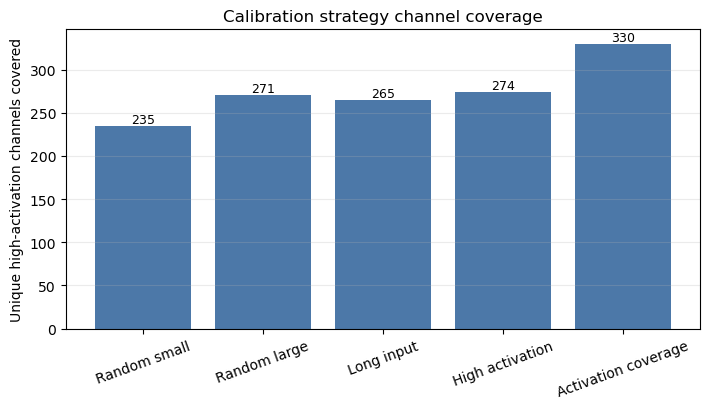

Saved figures\calibration_strategy_activation.pdf and figures\calibration_strategy_activation.png


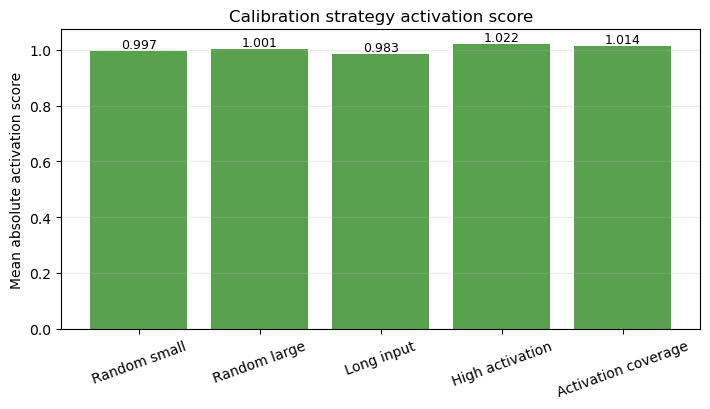

Saved figures\activation_score_scatter.pdf and figures\activation_score_scatter.png


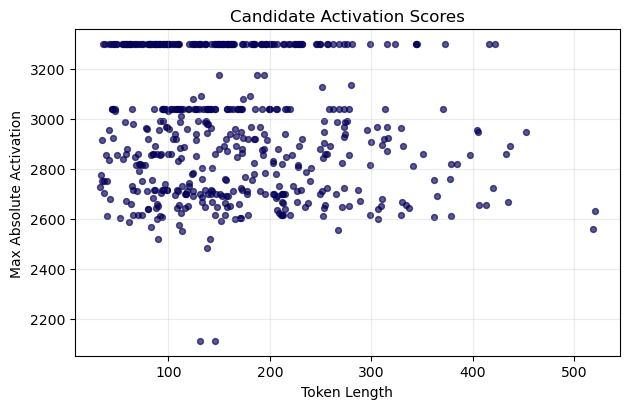

In [6]:
# Part 6 extension: calibration strategy plots
# Output files:
#   figures/calibration_strategy_coverage.pdf
#   figures/calibration_strategy_activation.pdf
#   figures/activation_score_scatter.pdf

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path("./results")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(exist_ok=True)

summary_df = pd.read_csv(RESULTS_DIR / "calibration_strategy_summary.csv")
scores_df = pd.read_csv(RESULTS_DIR / "activation_scores.csv")
strategy_labels = {
    "random_small": "Random small",
    "random_large": "Random large",
    "long_input": "Long input",
    "high_activation": "High activation",
    "activation_coverage": "Activation coverage",
}
summary_df["label"] = summary_df["strategy"].map(strategy_labels)


def save_plot(filename):
    pdf_path = FIGURES_DIR / f"{filename}.pdf"
    png_path = FIGURES_DIR / f"{filename}.png"
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=220, bbox_inches="tight")
    print(f"Saved {pdf_path} and {png_path}")


fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(summary_df["label"], summary_df["unique_channels_covered"], color="#4C78A8")
ax.set_ylabel("Unique high-activation channels covered")
ax.set_title("Calibration strategy channel coverage")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=20)
for idx, value in enumerate(summary_df["unique_channels_covered"]):
    ax.text(idx, value, f"{value:.0f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
save_plot("calibration_strategy_coverage")
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(summary_df["label"], summary_df["mean_activation_score"], color="#59A14F")
ax.set_ylabel("Mean absolute activation score")
ax.set_title("Calibration strategy activation score")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=20)
for idx, value in enumerate(summary_df["mean_activation_score"]):
    ax.text(idx, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
save_plot("calibration_strategy_activation")
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter(
    scores_df["token_length"],
    scores_df["max_abs_activation"],
    s=18,
    alpha=0.65,
    color="#040057",
)
ax.set_xlabel("Token Length")
ax.set_ylabel("Max Absolute Activation")
ax.set_title("Candidate Activation Scores")
ax.grid(alpha=0.25)
fig.tight_layout()
save_plot("activation_score_scatter")
plt.show()



,strategy,label,top_k_per_layer,unique_channels_covered
0,random_small,Random small,4,25
1,random_small,Random small,8,62
2,random_small,Random small,16,116
3,random_small,Random small,32,235
4,random_large,Random large,4,30
5,random_large,Random large,8,67
6,random_large,Random large,16,131
7,random_large,Random large,32,271
8,long_input,Long input,4,28
9,long_input,Long input,8,64


Saved: figures\coverage_topk_sensitivity_editable.pdf
Saved: figures\coverage_topk_sensitivity_editable.png


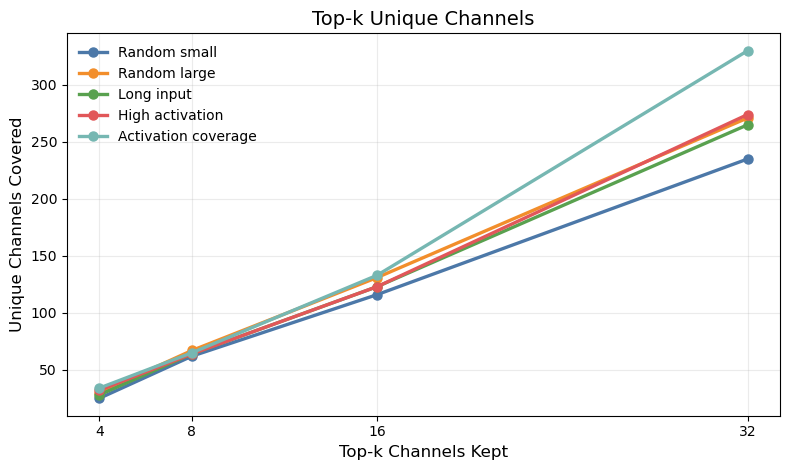

In [4]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Editable plot settings
# -----------------------------
PLOT_TITLE = "Top-k Unique Channels"
X_LABEL = "Top-k Channels Kept"
Y_LABEL = "Unique Channels Covered"
OUTPUT_NAME = "coverage_topk_sensitivity_editable"

TOP_K_VALUES = [4, 8, 16, 32]

STRATEGY_LABELS = {
    "random_small": "Random small",
    "random_large": "Random large",
    "long_input": "Long input",
    "high_activation": "High activation",
    "activation_coverage": "Activation coverage",
}

STRATEGY_COLORS = {
    "random_small": "#4C78A8",
    "random_large": "#F28E2B",
    "long_input": "#59A14F",
    "high_activation": "#E15759",
    "activation_coverage": "#76B7B2",
}

# -----------------------------
# Paths
# -----------------------------
RESULTS_DIR = Path("./results")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(exist_ok=True)

scores_df = pd.read_csv(RESULTS_DIR / "activation_scores.csv")

strategy_files = {
    "random_small": RESULTS_DIR / "calibration_random_small.jsonl",
    "random_large": RESULTS_DIR / "calibration_random_large.jsonl",
    "long_input": RESULTS_DIR / "calibration_long_input.jsonl",
    "high_activation": RESULTS_DIR / "calibration_high_activation.jsonl",
    "activation_coverage": RESULTS_DIR / "calibration_activation_coverage.jsonl",
}

# -----------------------------
# Helper functions
# -----------------------------
def parse_top_channels(channel_string, top_k_per_layer):
    """
    The saved top_channel_indices field stores channels layer by layer.
    This function keeps only the first k channels from each monitored layer.
    """
    channels_by_layer = {}

    for item in str(channel_string).split(";"):
        if not item or ":" not in item:
            continue

        layer, channel = item.split(":")
        layer = int(layer)
        channel = int(channel)

        channels_by_layer.setdefault(layer, []).append(f"{layer}:{channel}")

    kept_channels = []
    for layer in sorted(channels_by_layer):
        kept_channels.extend(channels_by_layer[layer][:top_k_per_layer])

    return kept_channels


def count_unique_channels(selected_df, top_k_per_layer):
    covered = set()

    for channel_string in selected_df["top_channel_indices"]:
        covered.update(parse_top_channels(channel_string, top_k_per_layer))

    return len(covered)


# -----------------------------
# Recalculate top-k sensitivity
# -----------------------------
rows = []

for strategy_name, jsonl_path in strategy_files.items():
    selected_ids = pd.read_json(jsonl_path, lines=True)["sample_id"].astype(int)
    selected_df = scores_df[scores_df["sample_id"].isin(selected_ids)]

    for top_k in TOP_K_VALUES:
        rows.append({
            "strategy": strategy_name,
            "label": STRATEGY_LABELS[strategy_name],
            "top_k_per_layer": top_k,
            "unique_channels_covered": count_unique_channels(selected_df, top_k),
        })

topk_df = pd.DataFrame(rows)
topk_df.to_csv(RESULTS_DIR / "coverage_topk_sensitivity.csv", index=False)

display(topk_df)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 4.8))

for strategy_name in strategy_files:
    plot_df = topk_df[topk_df["strategy"] == strategy_name]

    ax.plot(
        plot_df["top_k_per_layer"],
        plot_df["unique_channels_covered"],
        marker="o",
        linewidth=2.4,
        markersize=6.5,
        color=STRATEGY_COLORS[strategy_name],
        label=STRATEGY_LABELS[strategy_name],
    )

ax.set_title(PLOT_TITLE, fontsize=14)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel(Y_LABEL, fontsize=12)
ax.set_xticks(TOP_K_VALUES)
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()

pdf_path = FIGURES_DIR / f"{OUTPUT_NAME}.pdf"
png_path = FIGURES_DIR / f"{OUTPUT_NAME}.png"

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=220, bbox_inches="tight")

print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

plt.show()

Saved results\toy_awq_alpha_sweep.csv
Saved results\toy_awq_summary.csv
Saved results\toy_awq_channel_scales.csv
Best alpha: 0.70
Naive relative output error: 0.2709
Toy AWQ relative output error: 0.1195
Output error reduction vs naive: 55.9%


,method,bits,alpha,relative_weight_error,relative_output_error,output_error_reduction_vs_naive_pct
0,fp32_reference,32,NaN,0.000000,0.000000,NaN
1,naive_groupwise_int4,4,0.0,0.152998,0.270917,0.000000
2,toy_awq_scaled_int4,4,0.7,0.159349,0.119491,55.894005


,alpha,mean_scale_salient_channels,mean_scale_other_channels,relative_weight_error,relative_output_error
0,0.00,1.000000,1.000000,0.152998,0.270917
1,0.05,1.095110,0.980811,0.152047,0.246875
2,0.10,1.199269,0.961993,0.151327,0.227804
3,0.15,1.313336,0.943538,0.150676,0.208460
4,0.20,1.438256,0.925439,0.150077,0.190062
5,0.25,1.575060,0.907691,0.149644,0.173329
6,0.30,1.724879,0.890285,0.149392,0.161798
7,0.35,1.888953,0.873215,0.149382,0.152798
8,0.40,2.068637,0.856474,0.149450,0.142560
9,0.45,2.265417,0.840057,0.149716,0.134782


Saved figures\toy_awq_error_comparison.pdf
Saved figures\toy_awq_error_comparison.png


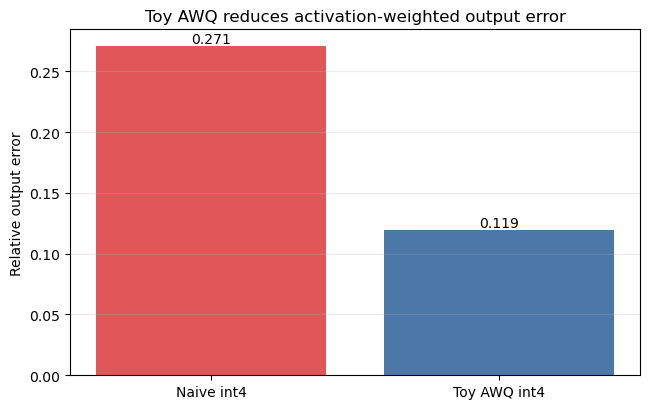

Saved figures\toy_awq_alpha_sweep.pdf
Saved figures\toy_awq_alpha_sweep.png


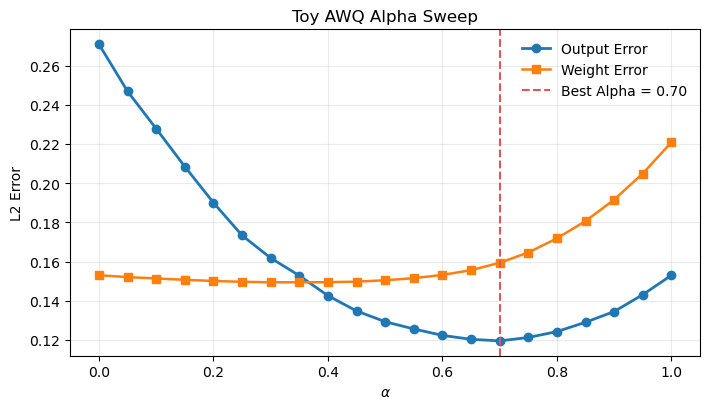

Saved figures\toy_awq_channel_scales.pdf
Saved figures\toy_awq_channel_scales.png


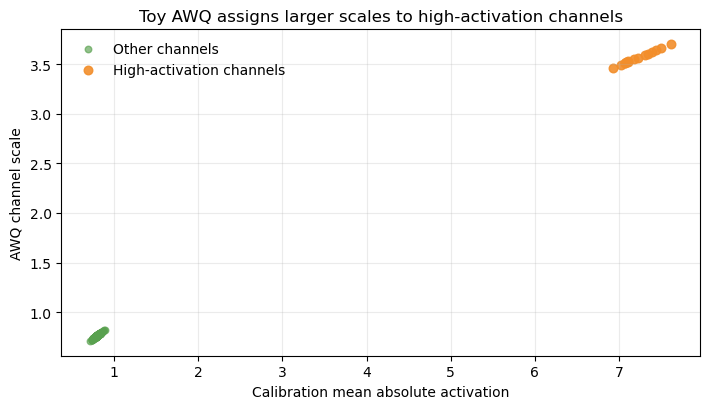

In [9]:
# Part 6 extension 2: toy AWQ mechanism experiment from scratch
# This cell manually implements the core AWQ scaling idea on a synthetic linear layer.
# It does not use AutoAWQ; the purpose is to make the mechanism visible.
# Output files:
#   results/toy_awq_summary.csv
#   results/toy_awq_alpha_sweep.csv
#   results/toy_awq_channel_scales.csv
#   figures/toy_awq_error_comparison.pdf
#   figures/toy_awq_alpha_sweep.pdf
#   figures/toy_awq_channel_scales.pdf

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

RESULTS_DIR = Path("./results")
FIGURES_DIR = Path("./figures")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

SEED = 1234
torch.manual_seed(SEED)
np.random.seed(SEED)

IN_FEATURES = 256
OUT_FEATURES = 128
N_CALIBRATION = 512
N_TEST = 512
SALIENT_FRACTION = 0.06
SALIENT_ACTIVATION_SCALE = 9.0
GROUP_SIZE = 32
BITS = 4
ALPHA_VALUES = [i / 20 for i in range(21)]

# Synthetic linear layer y = x W^T.
# A small subset of input channels has much larger activations; these are the
# channels that activation-aware quantisation should learn to protect.
W = torch.randn(OUT_FEATURES, IN_FEATURES, dtype=torch.float32) * 0.08
num_salient = max(1, int(IN_FEATURES * SALIENT_FRACTION))
salient_idx = torch.randperm(IN_FEATURES)[:num_salient]
salient_mask = torch.zeros(IN_FEATURES, dtype=torch.bool)
salient_mask[salient_idx] = True

# Add irrelevant outlier weight columns. This makes naive groupwise quantisation
# spend range on columns that are not very important for the input distribution.
non_salient_idx = torch.where(~salient_mask)[0]
outlier_cols = non_salient_idx[torch.randperm(len(non_salient_idx))[: max(1, IN_FEATURES // 12)]]
W[:, outlier_cols] *= 4.0
W[:, salient_idx] *= 0.7

activation_profile = torch.ones(IN_FEATURES)
activation_profile[salient_idx] = SALIENT_ACTIVATION_SCALE
X_cal = torch.randn(N_CALIBRATION, IN_FEATURES) * activation_profile
X_test = torch.randn(N_TEST, IN_FEATURES) * activation_profile
X_test[:, salient_idx] *= 1.10


def quantize_symmetric_groupwise(weight, bits=4, group_size=32):
    """Simple groupwise symmetric fake quantisation to int4 levels."""
    qmax = 2 ** (bits - 1) - 1
    qmin = -2 ** (bits - 1)
    _, in_features = weight.shape
    q_weight = torch.empty_like(weight)
    scale_blocks = []

    for start in range(0, in_features, group_size):
        end = min(start + group_size, in_features)
        block = weight[:, start:end]
        scale = block.abs().amax(dim=1, keepdim=True).clamp(min=1e-8) / qmax
        q = torch.round(block / scale).clamp(qmin, qmax)
        q_weight[:, start:end] = q * scale
        scale_blocks.append(scale)

    return q_weight, torch.cat(scale_blocks, dim=1)


def rel_l2(reference, approximation):
    return (reference - approximation).norm().item() / reference.norm().item()


Y_ref = X_test @ W.t()
Q_naive, _ = quantize_symmetric_groupwise(W, bits=BITS, group_size=GROUP_SIZE)
Y_naive = X_test @ Q_naive.t()

mean_abs_activation = X_cal.abs().mean(dim=0)
activation_importance = mean_abs_activation / mean_abs_activation.mean().clamp(min=1e-8)

sweep_rows = []
for alpha in ALPHA_VALUES:
    channel_scale = activation_importance.pow(alpha).clamp(0.25, 8.0)

    # AWQ-style equivalent transform:
    #   W[:, j] is scaled by s_j before quantisation.
    #   The inverse scale is folded back afterwards for this toy comparison.
    # In exact arithmetic this leaves y = x W^T unchanged, but after quantisation
    # it protects high-activation channels from output error.
    W_scaled = W * channel_scale.unsqueeze(0)
    Q_scaled, _ = quantize_symmetric_groupwise(W_scaled, bits=BITS, group_size=GROUP_SIZE)
    W_awq_equivalent = Q_scaled / channel_scale.unsqueeze(0)
    Y_awq = X_test @ W_awq_equivalent.t()

    sweep_rows.append({
        "alpha": alpha,
        "mean_scale_salient_channels": channel_scale[salient_mask].mean().item(),
        "mean_scale_other_channels": channel_scale[~salient_mask].mean().item(),
        "relative_weight_error": rel_l2(W, W_awq_equivalent),
        "relative_output_error": rel_l2(Y_ref, Y_awq),
    })

sweep_df = pd.DataFrame(sweep_rows)
best_row = sweep_df.loc[sweep_df["relative_output_error"].idxmin()].copy()
best_alpha = float(best_row["alpha"])
best_channel_scale = activation_importance.pow(best_alpha).clamp(0.25, 8.0)
Q_best_scaled, _ = quantize_symmetric_groupwise(W * best_channel_scale.unsqueeze(0), bits=BITS, group_size=GROUP_SIZE)
W_best_equivalent = Q_best_scaled / best_channel_scale.unsqueeze(0)
Y_best = X_test @ W_best_equivalent.t()

naive_output_error = rel_l2(Y_ref, Y_naive)
best_output_error = rel_l2(Y_ref, Y_best)
output_error_reduction_pct = 100 * (naive_output_error - best_output_error) / naive_output_error

summary_df = pd.DataFrame([
    {
        "method": "fp32_reference",
        "bits": 32,
        "alpha": np.nan,
        "relative_weight_error": 0.0,
        "relative_output_error": 0.0,
        "output_error_reduction_vs_naive_pct": np.nan,
    },
    {
        "method": "naive_groupwise_int4",
        "bits": BITS,
        "alpha": 0.0,
        "relative_weight_error": rel_l2(W, Q_naive),
        "relative_output_error": naive_output_error,
        "output_error_reduction_vs_naive_pct": 0.0,
    },
    {
        "method": "toy_awq_scaled_int4",
        "bits": BITS,
        "alpha": best_alpha,
        "relative_weight_error": rel_l2(W, W_best_equivalent),
        "relative_output_error": best_output_error,
        "output_error_reduction_vs_naive_pct": output_error_reduction_pct,
    },
])

channel_df = pd.DataFrame({
    "channel": np.arange(IN_FEATURES),
    "is_salient_channel": salient_mask.numpy(),
    "calibration_mean_abs_activation": mean_abs_activation.numpy(),
    "activation_importance": activation_importance.numpy(),
    "awq_scale_at_best_alpha": best_channel_scale.numpy(),
})

sweep_csv = RESULTS_DIR / "toy_awq_alpha_sweep.csv"
summary_csv = RESULTS_DIR / "toy_awq_summary.csv"
channel_csv = RESULTS_DIR / "toy_awq_channel_scales.csv"
sweep_df.to_csv(sweep_csv, index=False)
summary_df.to_csv(summary_csv, index=False)
channel_df.to_csv(channel_csv, index=False)

print(f"Saved {sweep_csv}")
print(f"Saved {summary_csv}")
print(f"Saved {channel_csv}")
print(f"Best alpha: {best_alpha:.2f}")
print(f"Naive relative output error: {naive_output_error:.4f}")
print(f"Toy AWQ relative output error: {best_output_error:.4f}")
print(f"Output error reduction vs naive: {output_error_reduction_pct:.1f}%")

try:
    display(summary_df)
    display(sweep_df)
except NameError:
    print(summary_df.to_string(index=False))
    print(sweep_df.to_string(index=False))

# Plot 1: error comparison.
fig, ax = plt.subplots(figsize=(6.6, 4.2))
plot_df = summary_df[summary_df["method"] != "fp32_reference"].copy()
labels = ["Naive int4", "Toy AWQ int4"]
colors = ["#E15759", "#4C78A8"]
ax.bar(labels, plot_df["relative_output_error"], color=colors)
ax.set_ylabel("Relative output error")
ax.set_title("Toy AWQ reduces activation-weighted output error")
ax.grid(axis="y", alpha=0.25)
for idx, value in enumerate(plot_df["relative_output_error"]):
    ax.text(idx, value, f"{value:.3f}", ha="center", va="bottom", fontsize=10)
fig.tight_layout()
for suffix in ("pdf", "png"):
    path = FIGURES_DIR / f"toy_awq_error_comparison.{suffix}"
    if suffix == "pdf":
        plt.savefig(path, bbox_inches="tight")
    else:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()

# Plot 2: alpha sweep.
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(sweep_df["alpha"], sweep_df["relative_output_error"], marker="o", linewidth=2.0, label="Output Error")
ax.plot(sweep_df["alpha"], sweep_df["relative_weight_error"], marker="s", linewidth=1.8, label="Weight Error")
ax.axvline(best_alpha, color="#E15759", linestyle="--", linewidth=1.5, label=f"Best Alpha = {best_alpha:.2f}")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("L2 Error")
ax.set_title("Toy AWQ Alpha Sweep")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
for suffix in ("pdf", "png"):
    path = FIGURES_DIR / f"toy_awq_alpha_sweep.{suffix}"
    if suffix == "pdf":
        plt.savefig(path, bbox_inches="tight")
    else:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()

# Plot 3: learned channel scales.
fig, ax = plt.subplots(figsize=(7.2, 4.2))
normal_df = channel_df[~channel_df["is_salient_channel"]]
salient_df = channel_df[channel_df["is_salient_channel"]]
ax.scatter(
    normal_df["calibration_mean_abs_activation"],
    normal_df["awq_scale_at_best_alpha"],
    s=22,
    alpha=0.65,
    label="Other channels",
    color="#59A14F",
)
ax.scatter(
    salient_df["calibration_mean_abs_activation"],
    salient_df["awq_scale_at_best_alpha"],
    s=38,
    alpha=0.9,
    label="High-activation channels",
    color="#F28E2B",
)
ax.set_xlabel("Calibration mean absolute activation")
ax.set_ylabel("AWQ channel scale")
ax.set_title("Toy AWQ assigns larger scales to high-activation channels")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
for suffix in ("pdf", "png"):
    path = FIGURES_DIR / f"toy_awq_channel_scales.{suffix}"
    if suffix == "pdf":
        plt.savefig(path, bbox_inches="tight")
    else:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()


In [ ]:
# Part 6 extension 2b: toy AWQ with activation-coverage calibration
# This cell extends the toy AWQ mechanism experiment by comparing how different
# synthetic calibration-set choices affect the AWQ scales and held-out output error.
# Output files:
#   results/toy_awq_coverage_calibration_summary.csv
#   results/toy_awq_coverage_alpha_sweep.csv
#   figures/toy_awq_coverage_strategy_comparison.pdf
#   figures/toy_awq_coverage_vs_error.pdf
#   figures/toy_awq_coverage_alpha_sweep.pdf

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

RESULTS_DIR = Path("./results")
FIGURES_DIR = Path("./figures")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

SEED = 2026
torch.manual_seed(SEED)
np.random.seed(SEED)

IN_FEATURES = 256
OUT_FEATURES = 128
N_CANDIDATES = 512
N_VALIDATION = 512
N_TEST = 1024
NUM_GROUPS = 12
ACTIVE_CHANNELS_PER_GROUP = 6
CALIBRATION_BUDGET = 16
TOP_K_CHANNELS = 8
GROUP_SIZE = 32
BITS = 4
ALPHA_VALUES = [i / 20 for i in range(21)]

feature_permutation = torch.randperm(IN_FEATURES)
active_groups = [
    feature_permutation[group_id * ACTIVE_CHANNELS_PER_GROUP:(group_id + 1) * ACTIVE_CHANNELS_PER_GROUP]
    for group_id in range(NUM_GROUPS)
]
salient_idx = torch.cat(active_groups)
salient_mask = torch.zeros(IN_FEATURES, dtype=torch.bool)
salient_mask[salient_idx] = True

W = torch.randn(OUT_FEATURES, IN_FEATURES, dtype=torch.float32) * 0.08
non_salient_idx = torch.where(~salient_mask)[0]
outlier_cols = non_salient_idx[torch.randperm(len(non_salient_idx))[: IN_FEATURES // 8]]
W[:, outlier_cols] *= 4.0
W[:, salient_idx] *= 0.65

group_probabilities = torch.tensor([0.32, 0.19, 0.12, 0.09, 0.07, 0.055, 0.045, 0.035, 0.025, 0.02, 0.015, 0.015])
group_probabilities = group_probabilities / group_probabilities.sum()
group_strengths = torch.linspace(14.0, 7.0, NUM_GROUPS)


def make_synthetic_activations(num_samples, balanced=False):
    X = torch.randn(num_samples, IN_FEATURES)
    if balanced:
        group_ids = torch.arange(num_samples) % NUM_GROUPS
        group_ids = group_ids[torch.randperm(num_samples)]
    else:
        group_ids = torch.multinomial(group_probabilities, num_samples, replacement=True)

    for sample_id, group_id in enumerate(group_ids.tolist()):
        X[sample_id, active_groups[group_id]] *= group_strengths[group_id]
        if torch.rand(()) < 0.08:
            secondary_group = torch.randint(0, NUM_GROUPS, (1,)).item()
            X[sample_id, active_groups[secondary_group]] *= group_strengths[secondary_group] * 0.5
    return X, group_ids


X_candidates, candidate_groups = make_synthetic_activations(N_CANDIDATES, balanced=False)
X_validation, _ = make_synthetic_activations(N_VALIDATION, balanced=True)
X_test, _ = make_synthetic_activations(N_TEST, balanced=True)


def quantize_symmetric_groupwise(weight, bits=4, group_size=32):
    qmax = 2 ** (bits - 1) - 1
    qmin = -2 ** (bits - 1)
    q_weight = torch.empty_like(weight)
    for start in range(0, weight.shape[1], group_size):
        end = min(start + group_size, weight.shape[1])
        block = weight[:, start:end]
        scale = block.abs().amax(dim=1, keepdim=True).clamp(min=1e-8) / qmax
        q = torch.round(block / scale).clamp(qmin, qmax)
        q_weight[:, start:end] = q * scale
    return q_weight


def rel_l2(reference, approximation):
    return (reference - approximation).norm().item() / reference.norm().item()


def top_channels_for_sample(sample):
    return set(torch.topk(sample.abs(), k=TOP_K_CHANNELS).indices.tolist())


candidate_channel_sets = [top_channels_for_sample(X_candidates[i]) for i in range(N_CANDIDATES)]


def greedy_activation_coverage_select():
    remaining = set(range(N_CANDIDATES))
    covered_channels = set()
    selected = []
    while len(selected) < CALIBRATION_BUDGET:
        best_idx = None
        best_gain = -1
        best_strength = -1.0
        for idx in remaining:
            gain = len(candidate_channel_sets[idx] - covered_channels)
            strength = X_candidates[idx].abs().mean().item()
            if gain > best_gain or (gain == best_gain and strength > best_strength):
                best_idx = idx
                best_gain = gain
                best_strength = strength
        selected.append(best_idx)
        covered_channels.update(candidate_channel_sets[best_idx])
        remaining.remove(best_idx)
    return torch.tensor(selected)


def count_covered_channels(indices):
    return len(set().union(*[candidate_channel_sets[int(idx)] for idx in indices.tolist()]))


random_generator = torch.Generator().manual_seed(SEED)
strategy_indices = {
    "random_16": torch.randperm(N_CANDIDATES, generator=random_generator)[:CALIBRATION_BUDGET],
    "high_magnitude_16": torch.topk(X_candidates.abs().mean(dim=1), k=CALIBRATION_BUDGET).indices,
    "activation_coverage_16": greedy_activation_coverage_select(),
    "full_candidate_512": torch.arange(N_CANDIDATES),
}
strategy_labels = {
    "naive_no_scaling": "Naive int4\nno scaling",
    "random_16": "Random\n16 samples",
    "high_magnitude_16": "High magnitude\n16 samples",
    "activation_coverage_16": "Activation coverage\n16 samples",
    "full_candidate_512": "Full candidate\n512 samples",
}
colors = {
    "naive_no_scaling": "#E15759",
    "random_16": "#4C78A8",
    "high_magnitude_16": "#F28E2B",
    "activation_coverage_16": "#72B7B2",
    "full_candidate_512": "#59A14F",
}

Y_validation_ref = X_validation @ W.t()
Y_test_ref = X_test @ W.t()
Q_naive = quantize_symmetric_groupwise(W, bits=BITS, group_size=GROUP_SIZE)
naive_validation_error = rel_l2(Y_validation_ref, X_validation @ Q_naive.t())
naive_test_error = rel_l2(Y_test_ref, X_test @ Q_naive.t())

summary_rows = [{
    "strategy": "naive_no_scaling",
    "label": strategy_labels["naive_no_scaling"],
    "samples": 0,
    "covered_channels": 0,
    "best_alpha": 0.0,
    "validation_output_error": naive_validation_error,
    "test_output_error": naive_test_error,
    "test_error_reduction_vs_naive_pct": 0.0,
    "mean_scale_salient_channels": 1.0,
    "mean_scale_other_channels": 1.0,
}]
alpha_rows = []

for strategy_name, selected_indices in strategy_indices.items():
    X_calibration = X_candidates[selected_indices]
    covered_channels = count_covered_channels(selected_indices)
    mean_abs_activation = X_calibration.abs().mean(dim=0)
    activation_importance = mean_abs_activation / mean_abs_activation.mean().clamp(min=1e-8)

    best = None
    for alpha in ALPHA_VALUES:
        channel_scale = activation_importance.pow(alpha).clamp(0.25, 8.0)
        W_scaled = W * channel_scale.unsqueeze(0)
        Q_scaled = quantize_symmetric_groupwise(W_scaled, bits=BITS, group_size=GROUP_SIZE)
        W_equivalent = Q_scaled / channel_scale.unsqueeze(0)
        validation_error = rel_l2(Y_validation_ref, X_validation @ W_equivalent.t())
        test_error = rel_l2(Y_test_ref, X_test @ W_equivalent.t())
        alpha_rows.append({
            "strategy": strategy_name,
            "label": strategy_labels[strategy_name],
            "alpha": alpha,
            "validation_output_error": validation_error,
            "test_output_error": test_error,
        })
        if best is None or validation_error < best["validation_output_error"]:
            best = {
                "alpha": alpha,
                "validation_output_error": validation_error,
                "test_output_error": test_error,
                "channel_scale": channel_scale,
            }

    summary_rows.append({
        "strategy": strategy_name,
        "label": strategy_labels[strategy_name],
        "samples": int(selected_indices.numel()),
        "covered_channels": covered_channels,
        "best_alpha": best["alpha"],
        "validation_output_error": best["validation_output_error"],
        "test_output_error": best["test_output_error"],
        "test_error_reduction_vs_naive_pct": 100 * (naive_test_error - best["test_output_error"]) / naive_test_error,
        "mean_scale_salient_channels": best["channel_scale"][salient_mask].mean().item(),
        "mean_scale_other_channels": best["channel_scale"][~salient_mask].mean().item(),
    })

summary_df = pd.DataFrame(summary_rows)
alpha_df = pd.DataFrame(alpha_rows)

summary_csv = RESULTS_DIR / "toy_awq_coverage_calibration_summary.csv"
alpha_csv = RESULTS_DIR / "toy_awq_coverage_alpha_sweep.csv"
summary_df.to_csv(summary_csv, index=False)
alpha_df.to_csv(alpha_csv, index=False)
print(f"Saved {summary_csv}")
print(f"Saved {alpha_csv}")
try:
    display(summary_df)
except NameError:
    print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.bar(summary_df["label"], summary_df["test_output_error"], color=[colors[s] for s in summary_df["strategy"]])
ax.set_ylabel("Held-out relative output error")
ax.set_title("Toy AWQ calibration strategy comparison")
ax.grid(axis="y", alpha=0.25)
for idx, value in enumerate(summary_df["test_output_error"]):
    ax.text(idx, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
for suffix in ("pdf", "png"):
    path = FIGURES_DIR / f"toy_awq_coverage_strategy_comparison.{suffix}"
    if suffix == "pdf":
        plt.savefig(path, bbox_inches="tight")
    else:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.4))
plot_df = summary_df[summary_df["strategy"] != "naive_no_scaling"]
for _, row in plot_df.iterrows():
    ax.scatter(row["covered_channels"], row["test_output_error"], s=80, color=colors[row["strategy"]])
    ax.annotate(row["label"].replace("\n", " "), (row["covered_channels"], row["test_output_error"]), xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel(f"Unique top-{TOP_K_CHANNELS} activation channels covered")
ax.set_ylabel("Held-out relative output error")
ax.set_title("More activation coverage gives better toy AWQ calibration")
ax.grid(alpha=0.25)
fig.tight_layout()
for suffix in ("pdf", "png"):
    path = FIGURES_DIR / f"toy_awq_coverage_vs_error.{suffix}"
    if suffix == "pdf":
        plt.savefig(path, bbox_inches="tight")
    else:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()

fig, ax = plt.subplots(figsize=(7.6, 4.4))
for strategy_name in strategy_indices:
    strategy_alpha = alpha_df[alpha_df["strategy"] == strategy_name]
    ax.plot(
        strategy_alpha["alpha"],
        strategy_alpha["validation_output_error"],
        marker="o",
        linewidth=2,
        label=strategy_labels[strategy_name].replace("\n", " "),
        color=colors[strategy_name],
    )
ax.set_xlabel(r"AWQ scale strength $\alpha$")
ax.set_ylabel("Validation relative output error")
ax.set_title("Toy AWQ alpha sweep by calibration strategy")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
for suffix in ("pdf", "png"):
    path = FIGURES_DIR / f"toy_awq_coverage_alpha_sweep.{suffix}"
    if suffix == "pdf":
        plt.savefig(path, bbox_inches="tight")
    else:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()


In [ ]:
# Extension: real Qwen layer AWQ alpha sweep and saliency comparison
# The heavy experiment is in run_real_layer_awq_ablation.py.
# To rerun it from this notebook, uncomment the next line:
# %run run_real_layer_awq_ablation.py

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")

alpha_df = pd.read_csv(RESULTS_DIR / "real_layer_awq_alpha_sweep.csv")
summary_df = pd.read_csv(RESULTS_DIR / "real_layer_awq_saliency_comparison.csv")
importance_df = pd.read_csv(RESULTS_DIR / "real_layer_awq_channel_importance.csv")

display(summary_df)

label_map = {
    "activation_magnitude": "Activation magnitude",
    "weight_norm": "Weight norm",
    "random_shuffled_activation": "Random shuffled activation",
}

plt.figure(figsize=(8.5, 5.2))
for method, group in alpha_df.groupby("saliency_method"):
    plt.plot(
        group["alpha"],
        group["relative_output_error"],
        marker="o",
        linewidth=2,
        label=label_map.get(method, method),
    )
plt.xlabel(r"AWQ scale strength $\alpha$")
plt.ylabel("Validation relative output error")
plt.title("Real Qwen layer alpha sweep")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plot_summary = summary_df.copy()
plot_summary["label"] = plot_summary["saliency_method"].map({
    "naive_rtn_no_scaling": "Naive RTN\nno scaling",
    "activation_magnitude": "Activation\nmagnitude",
    "weight_norm": "Weight\nnorm",
    "random_shuffled_activation": "Random\nshuffled",
})

plt.figure(figsize=(7.8, 4.8))
plt.bar(plot_summary["label"], plot_summary["best_relative_output_error"])
plt.ylabel("Best validation relative output error")
plt.title("Real-layer saliency signal comparison")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.4, 5.2))
plt.scatter(
    importance_df["activation_importance"],
    importance_df["weight_norm_importance"],
    s=12,
    alpha=0.35,
)
plt.scatter(
    importance_df.loc[importance_df["top32_activation"], "activation_importance"],
    importance_df.loc[importance_df["top32_activation"], "weight_norm_importance"],
    s=30,
    alpha=0.9,
    label="Top-32 activation channels",
)
plt.xlabel("Activation importance")
plt.ylabel("Weight-norm importance")
plt.title("Activation saliency is not the same as weight saliency")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Extension: real Qwen layer calibration-strategy comparison
# The heavy experiment is in run_real_layer_awq_calibration_strategy.py.
# To rerun it from this notebook, uncomment the next line:
# %run run_real_layer_awq_calibration_strategy.py

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")

calib_alpha_df = pd.read_csv(RESULTS_DIR / "real_layer_awq_calibration_strategy_alpha_sweep.csv")
calib_summary_df = pd.read_csv(RESULTS_DIR / "real_layer_awq_calibration_strategy_summary.csv")

display(calib_summary_df)

label_map = {
    "random_16": "Random 16 samples",
    "high_activation_16": "High activation 16 samples",
    "activation_coverage_16": "Activation coverage 16 samples",
}

naive_error = calib_summary_df.loc[
    calib_summary_df["calibration_strategy"] == "naive_rtn_no_scaling",
    "best_relative_output_error",
].iloc[0]

plt.figure(figsize=(8.5, 5.2))
for strategy, group in calib_alpha_df.groupby("calibration_strategy"):
    plt.plot(
        group["alpha"],
        group["relative_output_error"],
        marker="o",
        linewidth=2,
        label=label_map.get(strategy, strategy),
    )
plt.axhline(naive_error, linestyle="--", linewidth=1.6, color="0.55", label="Naive RTN no scaling")
plt.xlabel(r"AWQ scale strength $\alpha$")
plt.ylabel("Validation relative output error")
plt.title("Real-layer AWQ calibration strategy comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plot_summary = calib_summary_df.copy()
plot_summary["label"] = plot_summary["calibration_strategy"].map({
    "naive_rtn_no_scaling": "Naive RTN\nno scaling",
    "random_16": "Random\n16",
    "high_activation_16": "High activation\n16",
    "activation_coverage_16": "Activation coverage\n16",
})

plt.figure(figsize=(7.8, 4.8))
plt.bar(plot_summary["label"], plot_summary["best_relative_output_error"])
plt.ylabel("Best validation relative output error")
plt.title("Best real-layer output error by calibration strategy")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# Extension: real Qwen layer sweep for AWQ calibration strategies
# The heavy experiment is in run_real_layer_awq_layer_sweep.py.
# To rerun it from this notebook, uncomment the next line:
# %run run_real_layer_awq_layer_sweep.py

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")

layer_sweep_df = pd.read_csv(RESULTS_DIR / "real_layer_awq_layer_sweep_summary.csv")
display(layer_sweep_df)

label_map = {
    "naive_rtn_no_scaling": "Naive RTN",
    "random_16": "Random 16",
    "high_activation_16": "High activation 16",
    "activation_coverage_16": "Activation coverage 16",
}

plt.figure(figsize=(8.5, 5.2))
for strategy, group in layer_sweep_df.groupby("calibration_strategy"):
    plt.plot(
        group["layer_index"],
        group["best_relative_output_error"],
        marker="o",
        linewidth=2,
        label=label_map.get(strategy, strategy),
    )
plt.xlabel("Qwen layer index")
plt.ylabel("Best validation relative output error")
plt.title("Real-layer AWQ output error across layers")
plt.xticks(sorted(layer_sweep_df["layer_index"].unique()))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

non_naive = layer_sweep_df[layer_sweep_df["calibration_strategy"] != "naive_rtn_no_scaling"]
plt.figure(figsize=(8.5, 5.2))
for strategy, group in non_naive.groupby("calibration_strategy"):
    plt.plot(
        group["layer_index"],
        group["output_error_reduction_vs_naive_pct"],
        marker="o",
        linewidth=2,
        label=label_map.get(strategy, strategy),
    )
plt.xlabel("Qwen layer index")
plt.ylabel("Output error reduction vs naive RTN (%)")
plt.title("AWQ scaling improvement varies by layer")
plt.xticks(sorted(layer_sweep_df["layer_index"].unique()))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
